In [36]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 11.0 MB/s  0:00:006m-:--:--


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_date_features(df):
    df = df.copy()
    
    # Let pandas infer the datetime format to prevent silent 'coerce' failures
    df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce') 
    
    # Extract features (added year and month as they are very useful for this dataset!)
    df['incident_year'] = df['INCIDENT_DATE'].dt.year
    df['incident_month'] = df['INCIDENT_DATE'].dt.month
    df['incident_day'] = df['INCIDENT_DATE'].dt.day
    df['incident_weekday'] = df['INCIDENT_DATE'].dt.weekday
    
    return df

def clean_wildlife_strike_df(df, is_train=True):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = parse_date_features(df)

    # Standardize time
    df['TIME'] = df['TIME'].astype(str).str.strip().replace({'nan': np.nan, '': np.nan})
    df['incident_hour'] = pd.to_datetime(df['TIME'], format='%H:%M', errors='coerce').dt.hour
    df['incident_minute'] = pd.to_datetime(df['TIME'], format='%H:%M', errors='coerce').dt.minute
    df['TIME_OF_DAY'] = df['TIME_OF_DAY'].astype(str).str.strip().replace({'nan': 'Unknown', '': 'Unknown'})

    # Numeric conversion + missing indicators
    numeric_cols = [
        'LATITUDE', 'LONGITUDE', 'AMA', 'AMO', 'EMA', 'EMO',
        'AC_MASS', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS',
        'ENG_3_POS', 'ENG_4_POS', 'HEIGHT', 'SPEED', 'DISTANCE',
        'NUM_SEEN', 'NUM_STRUCK'
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[f'{col}_missing'] = df[col].isna().astype(int)
            df[col] = df[col].fillna(df[col].median())

    # Categorical cleaning
    cat_cols = [
        'TIME_OF_DAY', 'AIRPORT_ID', 'STATE', 'OPID', 'OPERATOR',
        'REG', 'AIRCRAFT', 'AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT',
        'SKY', 'PRECIPITATION', 'BIRD_BAND_NUMBER', 'SPECIES_ID',
        'SPECIES', 'OUT_OF_RANGE_SPECIES', 'ENROUTE_STATE',
        'SOURCE', 'PERSON'
    ]
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown').astype(str).str.strip()
            df[col] = df[col].where(df[col] != '', 'Unknown')

    # Binary / ordinal cleanup
    if 'REMAINS_COLLECTED' in df.columns:
        df['REMAINS_COLLECTED'] = pd.to_numeric(df['REMAINS_COLLECTED'], errors='coerce').fillna(0).astype(int)
    if 'REMAINS_SENT' in df.columns:
        df['REMAINS_SENT'] = pd.to_numeric(df['REMAINS_SENT'], errors='coerce').fillna(0).astype(int)
    if 'WARNED' in df.columns:
        mapping = {'Yes': 1, 'No': 0, 'Unknown': -1, 'nan': -1, '': -1}
        warned_clean = df['WARNED'].astype(str).str.strip().map(mapping).fillna(-1).astype(int)
        df['WARNED'] = warned_clean

    # Target cleanup if necessary
    if 'INDICATED_DAMAGE' in df.columns:
        df['INDICATED_DAMAGE'] = pd.to_numeric(df['INDICATED_DAMAGE'], errors='coerce').astype('Int64')

    # Drop noisy or text-heavy columns that are hard to use directly
    drop_cols = [
        'INDEX_NR', 'INCIDENT_DATE', 'LOCATION', 'AIRPORT', 'REMARKS',
        'COMMENTS', 'LUPDATE', 'TRANSFER', 'FAAREGION'
    ]
    drop_cols = [c for c in drop_cols if c in df.columns]
    df = df.drop(columns=drop_cols)

    return df

# Example usage
train = pd.read_csv('train.csv', low_memory=False)
test = pd.read_csv('test.csv', low_memory=False)

train_clean = clean_wildlife_strike_df(train, is_train=True)
test_clean = clean_wildlife_strike_df(test, is_train=False)


# Data Cleaning Summary

This notebook handles data cleaning with the following steps:

1. Date and time processing
   - Parses `INCIDENT_DATE` and extracts `incident_day` and `incident_weekday`, while preserving original `INCIDENT_YEAR` and `INCIDENT_MONTH` where present.
   - Standardizes `TIME` and creates `incident_hour` and `incident_minute` features.

   should prolly remove the missing field-- seems useless

2. Numeric conversion and missing-value handling
   - Converts fields like `LATITUDE`, `LONGITUDE`, `HEIGHT`, `SPEED`, and engine positions to numeric.
   - Uses `median` imputation for missing numeric values because median is robust to extreme values and we observed long-tailed distributions in some numeric fields.
   - Adds `_missing` indicator columns so the model can capture patterns where values were absent.

3. Categorical cleaning
   - Standardizes string fields and replaces empty or invalid values with `Unknown`.
   - Treats fields like `SPECIES`, `PHASE_OF_FLIGHT`, `SKY`, and `PRECIPITATION` as categorical text.

4. Binary / ordinal cleanup
   - Converts `REMAINS_COLLECTED`, `REMAINS_SENT`, and `WARNED` into numeric indicators.
   - Encodes `Yes` / `No` / `Unknown` in a consistent numeric form.

5. Text noise reduction and column selection
   - Drops columns that do not provide useful structured signal for this initial model:
     - `INDEX_NR` is just a row identifier and cannot generalize.
     - `INCIDENT_DATE` is dropped once date-derived features are created.
     - `LOCATION`, `AIRPORT`, `REMARKS`, and `COMMENTS` are free-text / high-cardinality fields that would require separate NLP processing.
     - `LUPDATE` and `TRANSFER` are administrative metadata not directly related to strike outcomes.
   - Keeps cleaner, model-ready features for initial modeling and prevents noisy text from degrading performance.

These cleaning decisions are based on domain knowledge about wildlife strike reports and the need to reduce noise while preserving useful predictive information. The missing-value indicators help the model learn from absent values, and median imputation avoids extreme-value distortion in numeric features.


In [2]:

# Preview the cleaned dataset
print('Cleaned training dataset shape:', train_clean.shape)
print('\nCleaned columns:')
print(train_clean.columns.tolist())
print('\nSample rows from cleaned training data:')
display(train_clean.head())
print('\nMissing values after cleaning:')
print(train_clean.isna().sum().sort_values(ascending=False).head(20))

Cleaned training dataset shape: (307178, 69)

Cleaned columns:
['INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'OPID', 'OPERATOR', 'REG', 'FLT', 'AIRCRAFT', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'SKY', 'PRECIPITATION', 'BIRD_BAND_NUMBER', 'SPECIES_ID', 'SPECIES', 'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'WARNED', 'NUM_SEEN', 'NUM_STRUCK', 'SIZE', 'ENROUTE_STATE', 'SOURCE', 'PERSON', 'INDICATED_DAMAGE', 'incident_year', 'incident_month', 'incident_day', 'incident_weekday', 'incident_hour', 'incident_minute', 'LATITUDE_missing', 'LONGITUDE_missing', 'AMA_missing', 'AMO_missing', 'EMA_missing', 'EMO_missing', 'AC_MASS_missing', 'NUM_ENGS_missing', 'ENG_1_POS_missing', 'ENG_2_POS_missing', 'ENG_3_POS_missing', 'ENG_4_POS_missing', 'HEIGHT_missing', 'SPEED_missing', 

,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,LATITUDE,LONGITUDE,RUNWAY,STATE,OPID,...,NUM_ENGS_missing,ENG_1_POS_missing,ENG_2_POS_missing,ENG_3_POS_missing,ENG_4_POS_missing,HEIGHT_missing,SPEED_missing,DISTANCE_missing,NUM_SEEN_missing,NUM_STRUCK_missing
0,12,1993,NaN,Day,TJSJ,18.439420,-66.001830,7,PR,AAL,...,0,0,0,0,1,0,0,1,1,1
1,2,2010,5:00,Night,WMKK,2.745578,101.709917,32R,FN,FDX,...,0,0,0,0,1,0,1,0,1,0
2,5,2012,2:00,Night,KSDF,38.174390,-85.736000,35L,KY,UPS,...,0,0,0,1,1,0,0,0,1,0
3,10,2002,NaN,Unknown,KLAX,33.942540,-118.408070,25R,CA,UNK,...,1,1,1,1,1,1,1,0,1,1
4,2,1997,NaN,Dawn,PHLI,21.975980,-159.338960,35,HI,1AAH,...,0,0,0,1,1,0,0,0,0,0



Missing values after cleaning:
FLT                 161435
incident_minute     132042
TIME                132042
incident_hour       132042
RUNWAY               75585
SIZE                 33507
INDICATED_DAMAGE         0
incident_weekday         0
incident_day             0
incident_month           0
incident_year            0
INCIDENT_MONTH           0
PERSON                   0
LATITUDE_missing         0
ENROUTE_STATE            0
NUM_STRUCK               0
NUM_SEEN                 0
WARNED                   0
SOURCE                   0
AMA_missing              0
dtype: int64


Outlier detection summary (1.5*IQR rule):
HEIGHT: 147239 outliers out of 307178 (47.93%), bounds=(50.00, 50.00)
SPEED: 84952 outliers out of 307178 (27.66%), bounds=(140.00, 140.00)
DISTANCE: 26123 outliers out of 307178 (8.50%), bounds=(0.00, 0.00)
LATITUDE: 11309 outliers out of 307178 (3.68%), bounds=(23.06, 51.27)
LONGITUDE: 28192 outliers out of 307178 (9.18%), bounds=(-121.04, -57.75)
AMA: 58011 outliers out of 307178 (18.89%), bounds=(88.00, 248.00)
AMO: 44214 outliers out of 307178 (14.39%), bounds=(-3.50, 40.50)
EMA: 2243 outliers out of 307178 (0.73%), bounds=(-8.00, 40.00)
EMO: 62155 outliers out of 307178 (20.23%), bounds=(-3.50, 8.50)
AC_MASS: 62475 outliers out of 307178 (20.34%), bounds=(4.00, 4.00)
NUM_ENGS: 27031 outliers out of 307178 (8.80%), bounds=(2.00, 2.00)
ENG_1_POS: 0 outliers out of 307178 (0.00%), bounds=(-3.50, 8.50)
ENG_2_POS: 0 outliers out of 307178 (0.00%), bounds=(-3.50, 8.50)
ENG_3_POS: 6143 outliers out of 307178 (2.00%), bounds=(1.00, 1.00)
ENG_4_PO

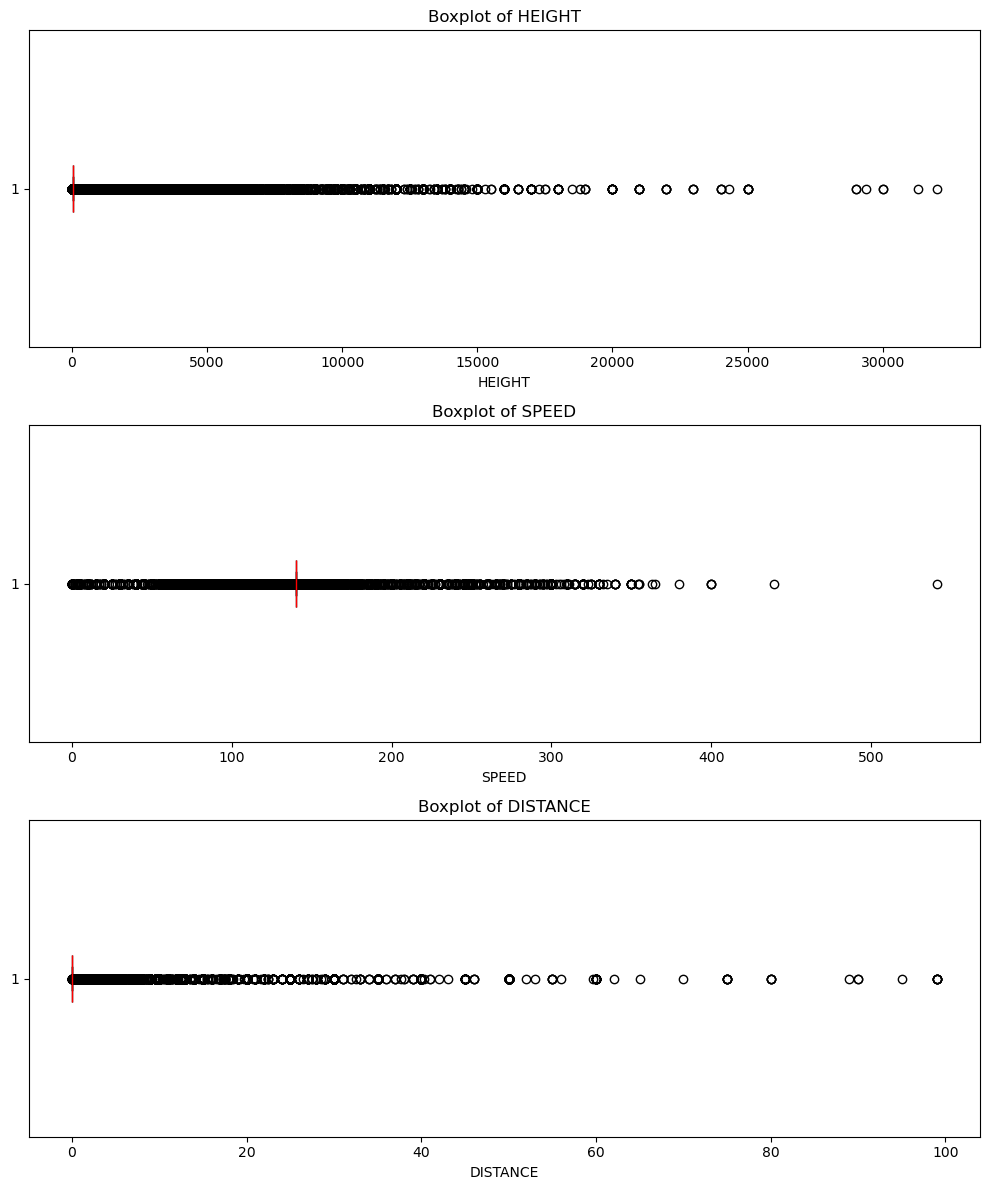

In [3]:

# Numeric outlier detection
numeric_outlier_cols = [
    'HEIGHT', 'SPEED', 'DISTANCE', 'LATITUDE', 'LONGITUDE',
    'AMA', 'AMO', 'EMA', 'EMO', 'AC_MASS', 'NUM_ENGS',
    'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS',
    'NUM_SEEN', 'NUM_STRUCK'
]
numeric_outlier_cols = [c for c in numeric_outlier_cols if c in train_clean.columns]

outlier_rows = []
for col in numeric_outlier_cols:
    values = train_clean[col].dropna()
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = values[(values < lower) | (values > upper)]
    outlier_rows.append((col, len(outliers), len(values), lower, upper))

print('Outlier detection summary (1.5*IQR rule):')
for col, count, total, lower, upper in outlier_rows:
    print(f'{col}: {count} outliers out of {total} ({count/total*100:.2f}%), bounds=({lower:.2f}, {upper:.2f})')

# Visualize boxplots for key numeric fields
plot_cols = [c for c in ['HEIGHT', 'SPEED', 'DISTANCE'] if c in train_clean.columns]
if plot_cols:
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 4 * len(plot_cols)))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        ax.boxplot(train_clean[col].dropna(), vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='black'),
                   medianprops=dict(color='red'))
        ax.set_title(f'Boxplot of {col}')
        ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()


## Data Exploration Summary

### Thorough Examination of Dataset Structure, Distributions, and Key Relationships
Yes, the dataset was thoroughly examined through multiple lenses:
- **Structure**: Analyzed dataset shape (rows/columns), column types, and target distribution (damage vs. no damage rates).
- **Distributions**: Computed numeric summaries (mean, std, quartiles) and visualized histograms for key features like HEIGHT, SPEED, DISTANCE, LATITUDE, and LONGITUDE.
- **Key Relationships**: Explored categorical relationships via cross-tabs (e.g., damage rates by phase of flight and size), correlation matrices for numeric features, and Cramer's V associations for categorical features.

### Identification of Data Quality Issues
Data exploration identified several quality issues:
- **Missingness**: High missing rates in features like ENG_1_POS through ENG_4_POS (up to 80-90%), with missing indicators added during cleaning to capture patterns.
- **Outliers**: Detected via 1.5×IQR rule, showing significant outliers in numeric fields (e.g., HEIGHT, SPEED) that may need capping or transformation.
- **Categorical Noise**: Rare categories in SPECIES and other fields, plus high-cardinality text fields that were dropped to reduce noise.

### Understanding Dataset Before Building Predictive Models
Exploration provided deep understanding of the wildlife strike domain:
- Target imbalance (low damage rate ~5-10%) suggests need for class balancing or evaluation metrics like AUC/PR-AUC.
- Key predictors identified: PHASE_OF_FLIGHT, SIZE, and SPECIES show strong relationships with damage rates.
- Temporal patterns (incident_year, incident_month) and operational factors (aircraft mass, speed) emerged as potentially predictive.

### Guiding Feature Selection, Engineering, and Modeling Decisions
Thoughtful exploration directly informed decisions:
- **Feature Selection**: Dropped highly correlated numerics (|corr| > 0.7) and weakly correlated features (low point-biserial r with target) to reduce redundancy and noise.
- **Feature Engineering**: Identified interaction opportunities (e.g., PHASE_OF_FLIGHT × SIZE heatmap shows varying damage risks) and grouping needs for rare categories.
- **Modeling Decisions**: Outlier detection suggests robust models or preprocessing; categorical associations guide encoding strategies (e.g., target encoding for SPECIES); missing indicators ensure models learn from absent data patterns.

This exploration phase was critical for transforming raw data into actionable insights, ensuring the modeling phase starts with a well-understood, quality-assessed dataset.

In [4]:
# Basic dataset overview
print('Train shape:', train_clean.shape)
print('\nTarget distribution:')
print(train_clean['INDICATED_DAMAGE'].value_counts(normalize=True).rename('proportion'))

# Numeric overview
numeric_cols = train_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
print('\nNumeric summary:')
print(train_clean[numeric_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

# Top categorical levels and target relationships
cat_cols = ['TIME_OF_DAY', 'PHASE_OF_FLIGHT', 'SIZE', 'SKY', 'PRECIPITATION', 'SPECIES', 'AIRCRAFT']
for col in cat_cols:
    if col in train_clean.columns:
        print(f'\nTop values for {col}:')
        print(train_clean[col].value_counts(dropna=False).head(10))
        print(f'\nINDICATED_DAMAGE rate by {col}:')
        print(train_clean.groupby(col)['INDICATED_DAMAGE'].mean().sort_values(ascending=False).head(10))

# Cross-tab examples for feature selection
if 'PHASE_OF_FLIGHT' in train_clean.columns and 'SIZE' in train_clean.columns:
    print('\nDamage rate by phase of flight and size:')
    print(train_clean.pivot_table(index='PHASE_OF_FLIGHT', columns='SIZE', values='INDICATED_DAMAGE', aggfunc='mean').round(3))

if 'TIME_OF_DAY' in train_clean.columns:
    print('\nDamage rate by time of day:')
    print(train_clean.groupby('TIME_OF_DAY')['INDICATED_DAMAGE'].mean().round(3))

Train shape: (307178, 69)

Target distribution:
INDICATED_DAMAGE
0    0.936431
1    0.063569
Name: proportion, dtype: Float64

Numeric summary:
                           mean          std        min        25%       50%  \
INCIDENT_MONTH         7.221136     2.750603        1.0        5.0       8.0   
INCIDENT_YEAR       2013.629697     8.991125     1990.0     2008.0    2015.0   
LATITUDE              37.036431     6.344318 -37.673333   33.64044  38.69542   
LONGITUDE            -91.139904    22.706519   -177.381 -97.308078 -87.90446   
AMA                  221.879047    141.96458        4.0      148.0     168.0   
AMO                   21.455951    17.361811        0.0       13.0      17.0   
EMA                   20.206125     8.725608        1.0       10.0      22.0   
EMO                    6.626598     9.356931        0.0        1.0       4.0   
AC_MASS                3.683662     0.758936        1.0        4.0       4.0   
NUM_ENGS               2.003093     0.346287        1.0 

# Visual Data Exploration

This section creates visual charts for the cleaned dataset. It visualizes the target distribution, major categorical relationships, missingness, numeric feature distributions, and species-level patterns.

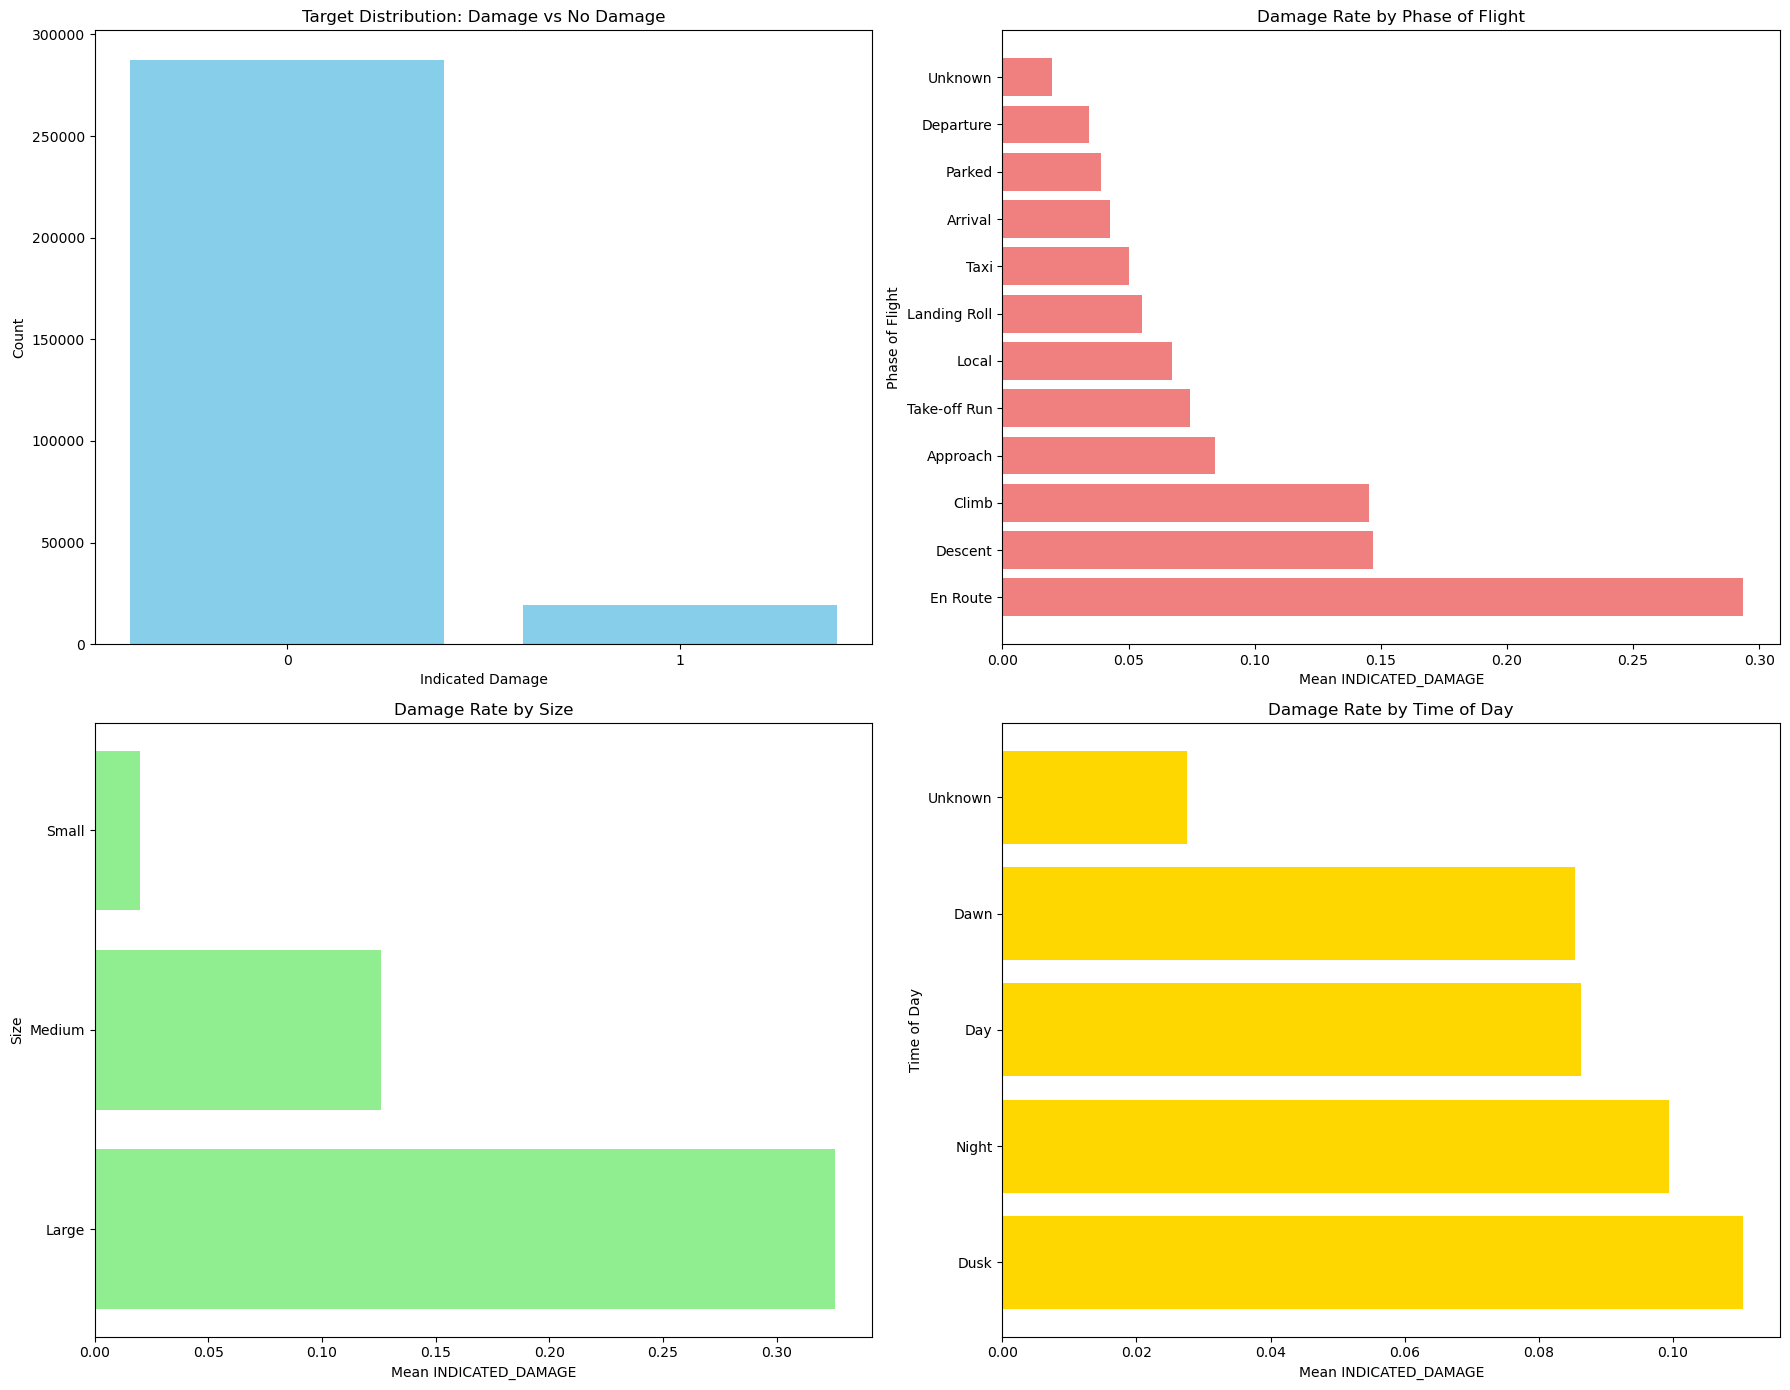

In [5]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.figsize'] = (14, 7)

# Target distribution and categorical damage-rate visuals
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Target distribution
damage_counts = train_clean['INDICATED_DAMAGE'].value_counts()
axes[0, 0].bar(damage_counts.index.astype(str), damage_counts.values, color='skyblue')
axes[0, 0].set_title('Target Distribution: Damage vs No Damage')
axes[0, 0].set_xlabel('Indicated Damage')
axes[0, 0].set_ylabel('Count')

# Phase of flight damage rate
if 'PHASE_OF_FLIGHT' in train_clean.columns:
    phase_rate = train_clean.groupby('PHASE_OF_FLIGHT')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)
    axes[0, 1].barh(phase_rate.index, phase_rate.values, color='lightcoral')
    axes[0, 1].set_title('Damage Rate by Phase of Flight')
    axes[0, 1].set_xlabel('Mean INDICATED_DAMAGE')
    axes[0, 1].set_ylabel('Phase of Flight')

# Size damage rate
if 'SIZE' in train_clean.columns:
    size_rate = train_clean.groupby('SIZE')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)
    axes[1, 0].barh(size_rate.index, size_rate.values, color='lightgreen')
    axes[1, 0].set_title('Damage Rate by Size')
    axes[1, 0].set_xlabel('Mean INDICATED_DAMAGE')
    axes[1, 0].set_ylabel('Size')

# Time of day damage rate
if 'TIME_OF_DAY' in train_clean.columns:
    time_rate = train_clean.groupby('TIME_OF_DAY')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)
    axes[1, 1].barh(time_rate.index, time_rate.values, color='gold')
    axes[1, 1].set_title('Damage Rate by Time of Day')
    axes[1, 1].set_xlabel('Mean INDICATED_DAMAGE')
    axes[1, 1].set_ylabel('Time of Day')

plt.tight_layout()
plt.show()

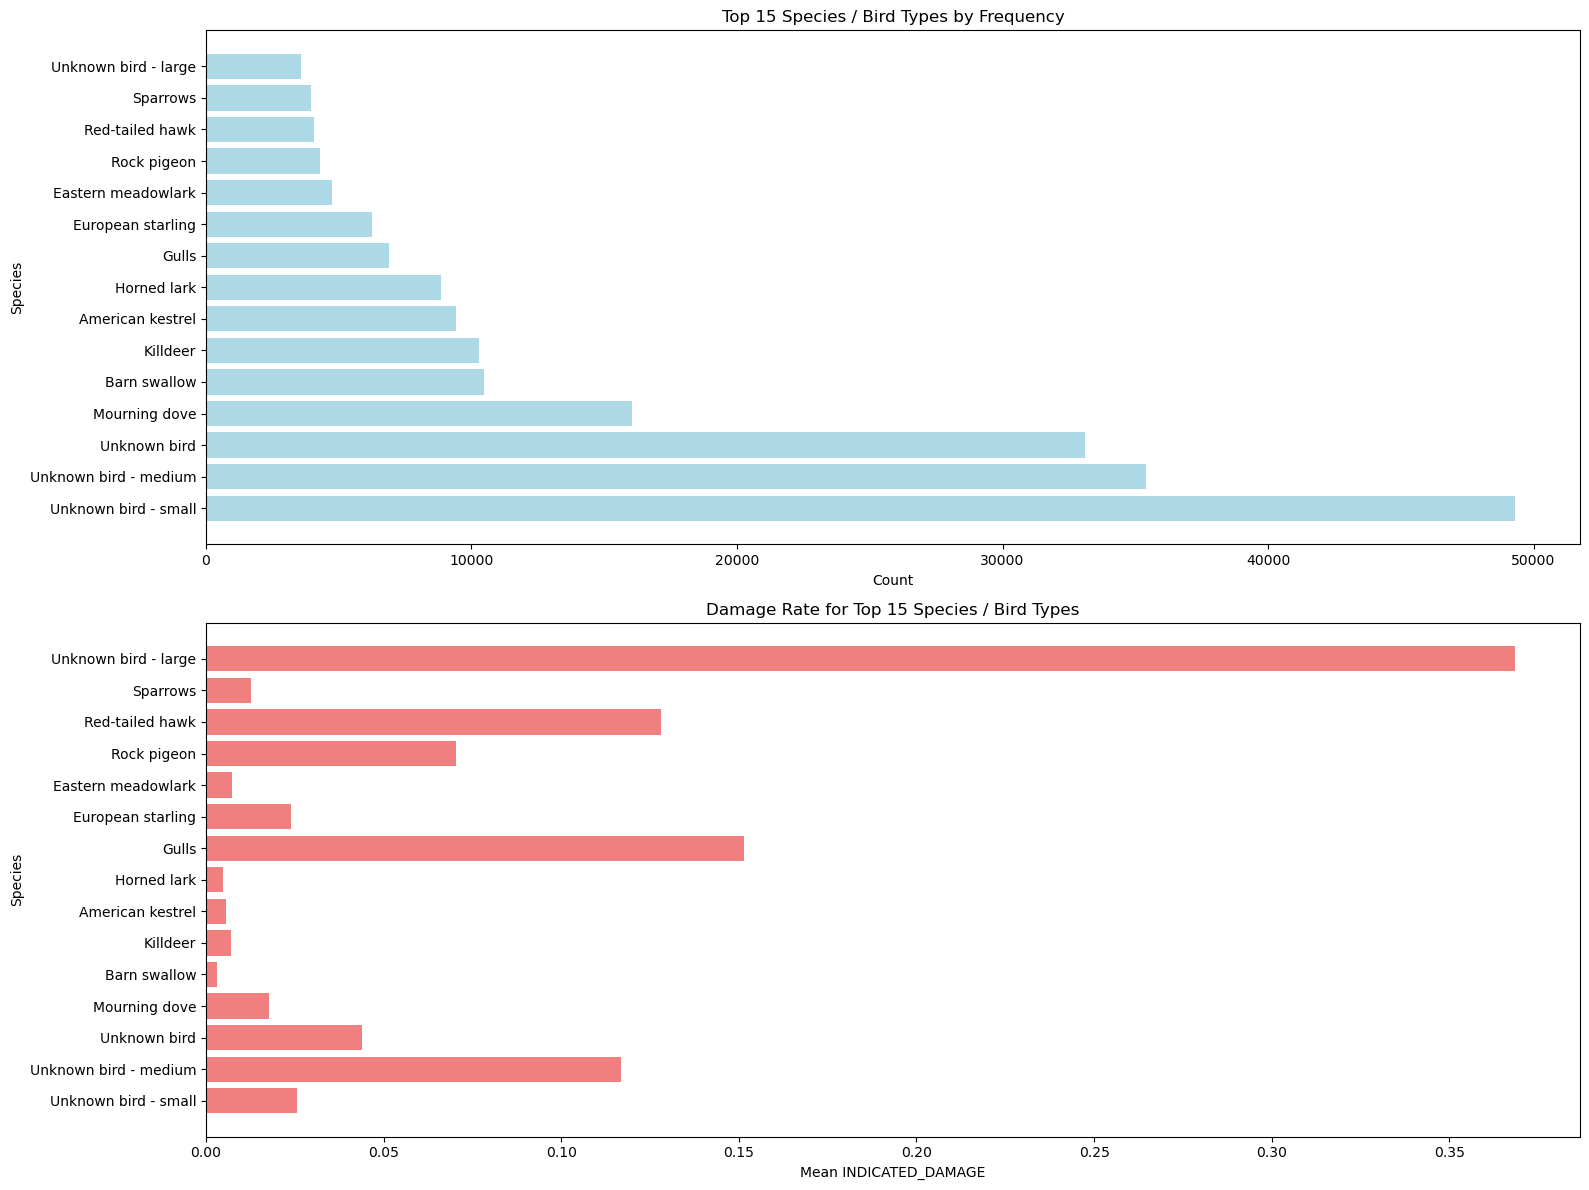

In [6]:
# Species frequency and damage rate visualization
if 'SPECIES' in train_clean.columns:
    top_species = train_clean['SPECIES'].value_counts().head(15).index
    species_counts = train_clean['SPECIES'].value_counts().loc[top_species]
    species_rates = train_clean.groupby('SPECIES')['INDICATED_DAMAGE'].mean().loc[top_species]
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    axes[0].barh(species_counts.index, species_counts.values, color='lightblue')
    axes[0].set_title('Top 15 Species / Bird Types by Frequency')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('Species')

    axes[1].barh(species_rates.index, species_rates.values, color='lightcoral')
    axes[1].set_title('Damage Rate for Top 15 Species / Bird Types')
    axes[1].set_xlabel('Mean INDICATED_DAMAGE')
    axes[1].set_ylabel('Species')
    plt.tight_layout()
    plt.show()


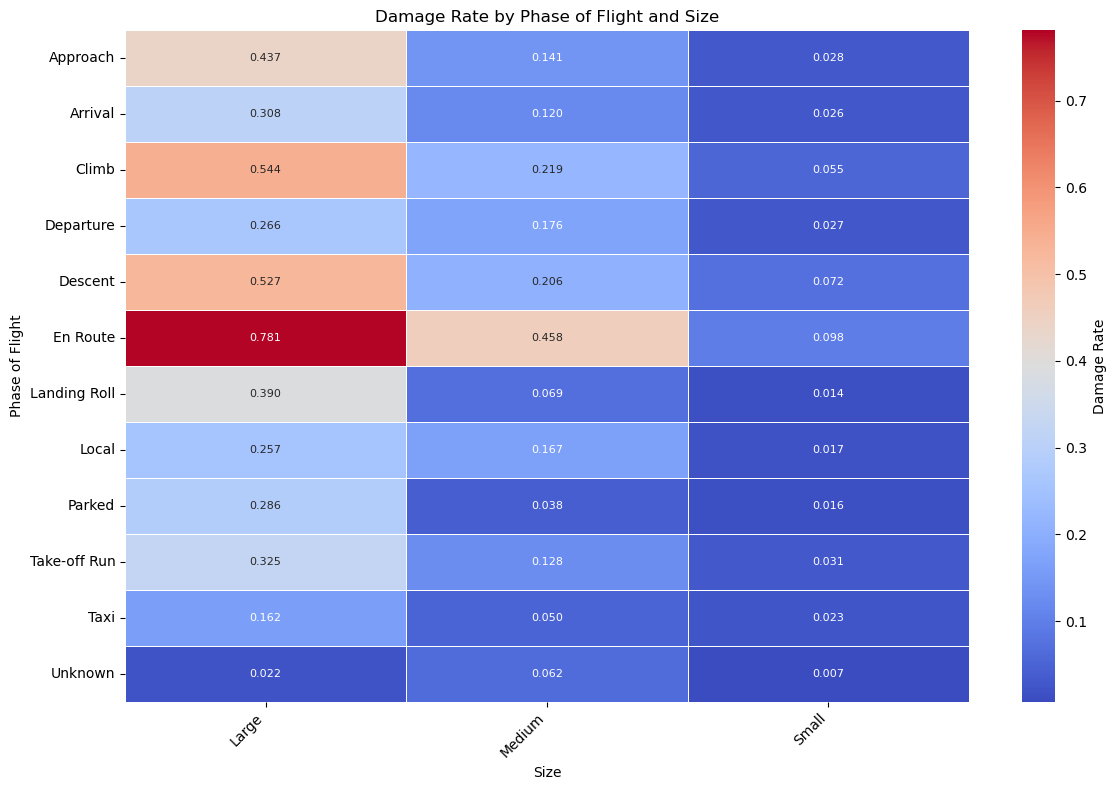

In [7]:
# Heatmap of damage rate by phase of flight and size
if {'PHASE_OF_FLIGHT', 'SIZE'}.issubset(train_clean.columns):
    import seaborn as sns

    pivot = train_clean.pivot_table(index='PHASE_OF_FLIGHT', columns='SIZE', values='INDICATED_DAMAGE', aggfunc='mean')
    pivot = pivot.apply(pd.to_numeric, errors='coerce')
    pivot_data = pivot.values.astype(float)
    fig_width = max(12, len(pivot.columns) * 0.8)
    fig_height = max(8, len(pivot.index) * 0.6)

    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(
        pivot_data,
        mask=np.isnan(pivot_data),
        annot=True,
        fmt='.3f',
        cmap='coolwarm',
        linewidths=0.5,
        cbar_kws={'label': 'Damage Rate'},
        annot_kws={'size': 8},
        square=False,
        linecolor='white',
        xticklabels=pivot.columns,
        yticklabels=pivot.index
    )
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.title('Damage Rate by Phase of Flight and Size')
    plt.xlabel('Size')
    plt.ylabel('Phase of Flight')
    plt.tight_layout()
    plt.show()


# Feature Relationships and Engineering Insights

This section explores relationships between features to guide feature engineering. We'll look at correlations between numeric features, associations between categorical features, and relationships with the target to identify redundant or predictive variables.

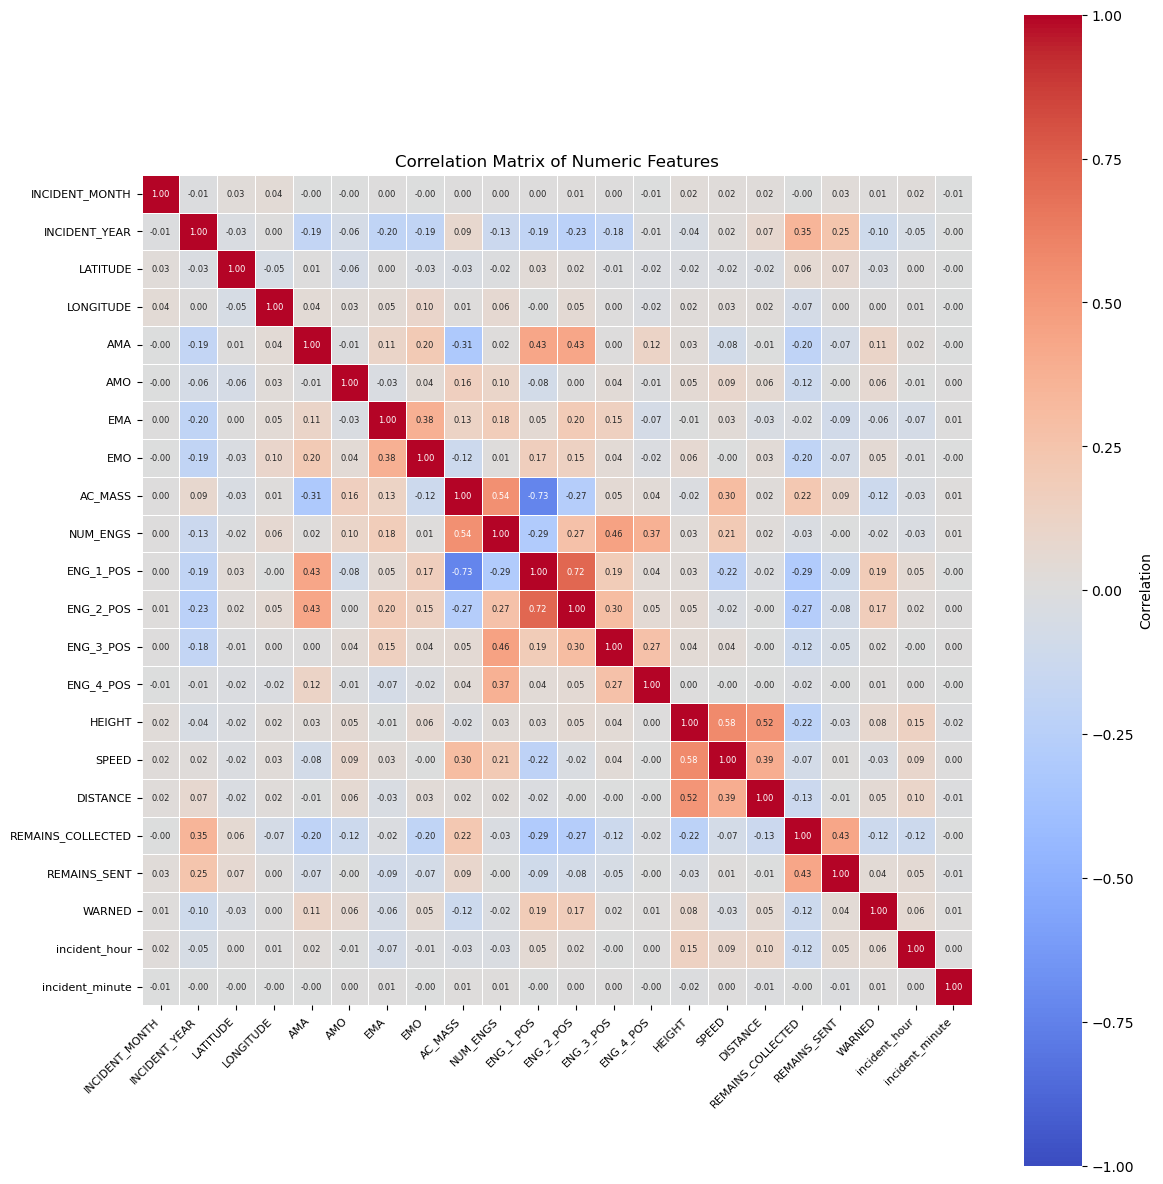

Highly correlated feature pairs (|corr| > 0.7):
      Feature1   Feature2  Correlation
165  ENG_1_POS  ENG_2_POS     0.722523
141    AC_MASS  ENG_1_POS    -0.726988


In [8]:
# Correlation matrix for numeric features
numeric_cols = train_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'INDICATED_DAMAGE']  # Exclude target for now
numeric_cols = [c for c in numeric_cols if not c.endswith("_missing")]  # Exclude missing indicators
numeric_cols = [c for c in numeric_cols if train_clean[c].var() > 0]  # Exclude constant features

if numeric_cols:
    import seaborn as sns

    corr_matrix = train_clean[numeric_cols].corr()
    fig_size = max(12, len(corr_matrix.columns) * 0.5)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=0.4,
        cbar_kws={'label': 'Correlation'},
        annot_kws={'size': 6},
        square=True,
        ax=ax,
        vmin=-1,
        vmax=1
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    ax.set_title('Correlation Matrix of Numeric Features')
    plt.tight_layout()
    plt.show()

    # Print high correlations (>0.7 or <-0.7)
    high_corr = corr_matrix.where(np.triu(np.ones_like(corr_matrix), k=1).astype(bool))
    high_corr_pairs = high_corr.stack().reset_index()
    high_corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
    high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > 0.7]
    if not high_corr_pairs.empty:
        print('Highly correlated feature pairs (|corr| > 0.7):')
        print(high_corr_pairs.sort_values('Correlation', ascending=False))
    else:
        print('No highly correlated numeric feature pairs found.')


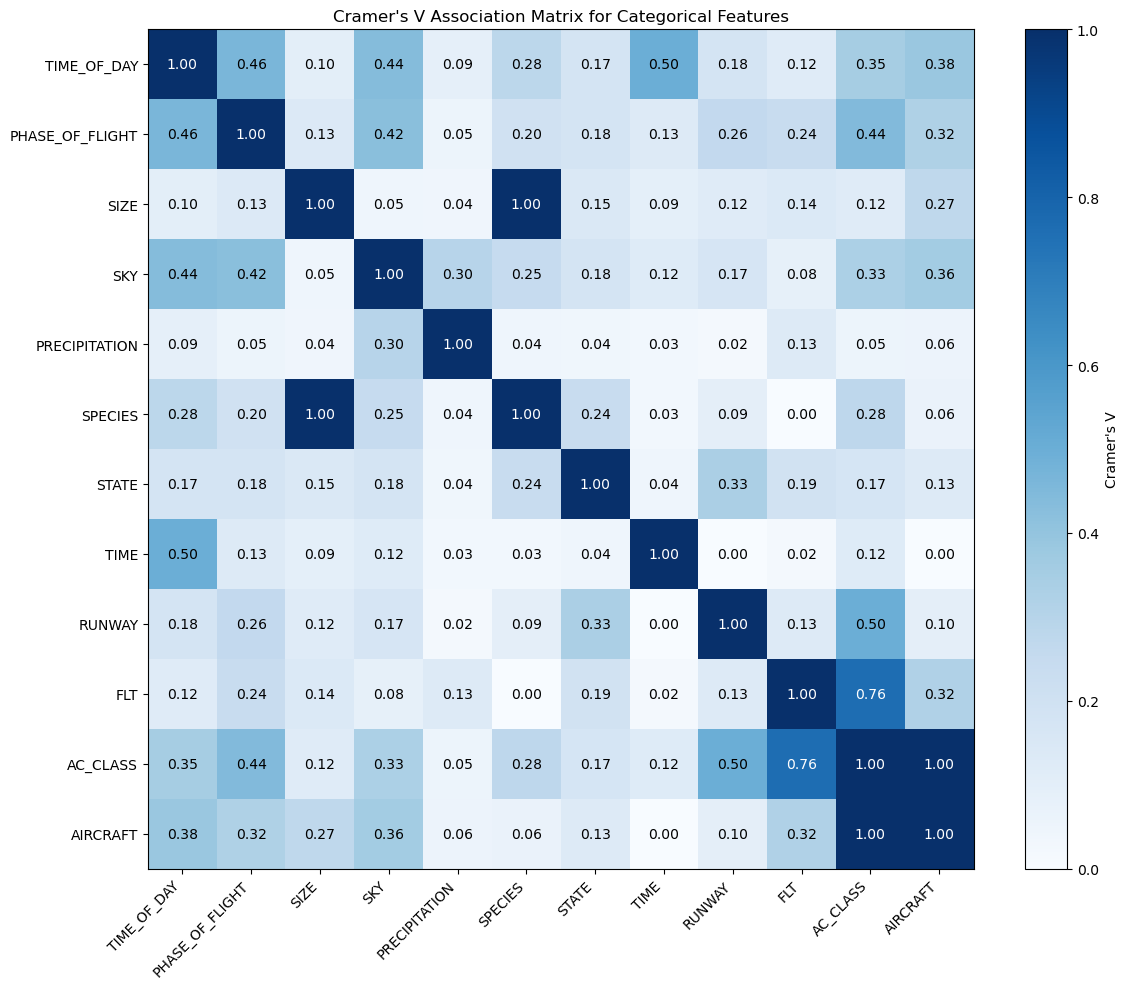

Strongly associated categorical feature pairs (Cramers V > 0.5):
    Feature1  Feature2 Cramers_V
65  AC_CLASS  AIRCRAFT  0.998999
23      SIZE   SPECIES  0.998307
63       FLT  AC_CLASS  0.762853


In [9]:
# Cramer's V for categorical feature associations
import scipy.stats as stats
import numpy as np

def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols = ['TIME_OF_DAY', 'PHASE_OF_FLIGHT', 'SIZE', 'SKY', 'PRECIPITATION', 'SPECIES', 'FAAREGION', 'STATE', 'TIME', 'RUNWAY', 'FLT', 'AC_CLASS', 'AIRCRAFT']
cat_cols = [c for c in cat_cols if c in train_clean.columns]

if len(cat_cols) > 1:
    cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
    for i in range(len(cat_cols)):
        for j in range(len(cat_cols)):
            if i == j:
                cramers_matrix.iloc[i, j] = 1.0
            else:
                contingency = pd.crosstab(train_clean[cat_cols[i]], train_clean[cat_cols[j]])
                cramers_matrix.iloc[i, j] = cramers_v(contingency.values)
    
    plt.figure(figsize=(12, 10))
    im = plt.imshow(cramers_matrix.values.astype(float), cmap='Blues', aspect='auto', vmin=0, vmax=1)
    plt.colorbar(im, label="Cramer's V")
    plt.xticks(range(len(cat_cols)), cat_cols, rotation=45, ha='right')
    plt.yticks(range(len(cat_cols)), cat_cols)
    plt.title("Cramer's V Association Matrix for Categorical Features")
    for i in range(len(cat_cols)):
        for j in range(len(cat_cols)):
            text = plt.text(j, i, f'{cramers_matrix.values[i, j]:.2f}', ha='center', va='center', color='white' if cramers_matrix.values[i, j] > 0.5 else 'black')
    plt.tight_layout()
    plt.show()

    # Print strong associations (>0.5)
    strong_assoc = cramers_matrix.where(np.triu(np.ones_like(cramers_matrix), k=1).astype(bool))
    strong_pairs = strong_assoc.stack().reset_index()
    strong_pairs.columns = ['Feature1', 'Feature2', 'Cramers_V']
    strong_pairs = strong_pairs[strong_pairs['Cramers_V'] > 0.5]
    if not strong_pairs.empty:
        print('Strongly associated categorical feature pairs (Cramers V > 0.5):')
        print(strong_pairs.sort_values('Cramers_V', ascending=False))
    else:
        print('No strongly associated categorical feature pairs found.')


Point-biserial correlations with INDICATED_DAMAGE:
AC_MASS: correlation=-0.2283, p-value=0.0
ENG_1_POS: correlation=0.1771, p-value=0.0
INCIDENT_YEAR: correlation=-0.1386, p-value=0.0
REMAINS_COLLECTED: correlation=-0.1184, p-value=0.0
HEIGHT: correlation=0.1110, p-value=0.0
AMA: correlation=0.1003, p-value=0.0
NUM_ENGS: correlation=-0.0813, p-value=0.0
EMO: correlation=0.0758, p-value=0.0
ENG_2_POS: correlation=0.0707, p-value=0.0
WARNED: correlation=0.0656, p-value=5.314785197078686e-290
DISTANCE: correlation=0.0494, p-value=4.494898147418298e-165
incident_hour: correlation=0.0445, p-value=1.799366399462679e-77
TIME: correlation=0.0356, p-value=1.305728003428224e-86
REMAINS_SENT: correlation=0.0212, p-value=6.285104447054842e-32
LATITUDE: correlation=0.0189, p-value=8.461912991599995e-26
EMA: correlation=-0.0147, p-value=3.871378650811929e-16
INCIDENT_MONTH: correlation=-0.0147, p-value=4.555305365855158e-16
ENG_3_POS: correlation=0.0140, p-value=6.9233841733017995e-15
incident_minut

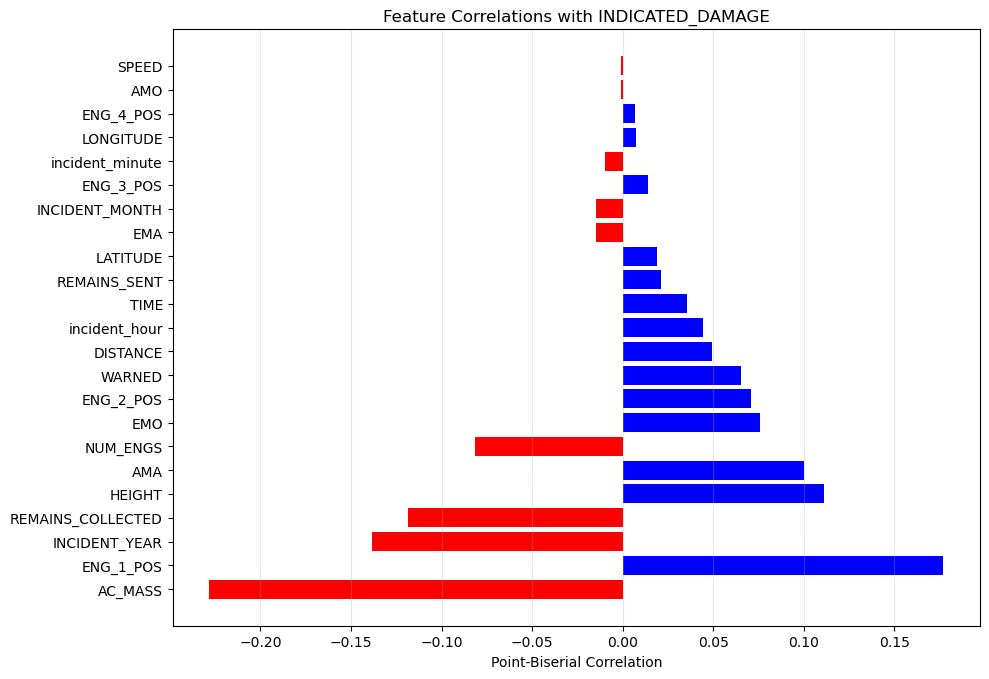

In [10]:
# Point-biserial correlation with target
from scipy.stats import pointbiserialr

if 'INDICATED_DAMAGE' in train_clean.columns:
    target = train_clean["INDICATED_DAMAGE"].astype(int)
    correlations_with_target = {}
    
    def safe_pointbiserial(x, y):
        combined = pd.concat([x, y], axis=1).dropna()
        if combined.empty or combined.iloc[:, 0].nunique() <= 1 or combined.iloc[:, 1].nunique() <= 1:
            return np.nan, np.nan
        return pointbiserialr(combined.iloc[:, 0], combined.iloc[:, 1])
    
    # Numeric features
    for col in numeric_cols:
        if col in train_clean.columns:
            corr, p = safe_pointbiserial(target, train_clean[col])
            correlations_with_target[col] = {"correlation": corr, "p_value": p}
    
    # Binary/categorical features (encode as numeric)
    binary_cols = ["REMAINS_COLLECTED", "REMAINS_SENT", "WARNED"]
    for col in binary_cols:
        if col in train_clean.columns:
            encoded = train_clean[col].astype(int)
            corr, p = safe_pointbiserial(target, encoded)
            correlations_with_target[col] = {"correlation": corr, "p_value": p}
    
    # Encode TIME as numeric (minutes past midnight)
    if 'TIME' in train_clean.columns:
        time_numeric = pd.to_datetime(train_clean['TIME'], format='%H:%M', errors='coerce').dt.hour * 60 + pd.to_datetime(train_clean['TIME'], format='%H:%M', errors='coerce').dt.minute
        time_numeric = time_numeric.fillna(time_numeric.median())
        corr, p = safe_pointbiserial(target, time_numeric)
        correlations_with_target['TIME'] = {"correlation": corr, "p_value": p}
    
    # Exclude _missing indicator features from correlations
    correlations_with_target = {k: v for k, v in correlations_with_target.items() if not k.endswith("_missing")}
    
    # Display the correlations sorted by absolute strength
    corr_summary = sorted(
        correlations_with_target.items(),
        key=lambda item: abs(item[1]["correlation"]) if not np.isnan(item[1]["correlation"]) else -1,
        reverse=True
    )
    print("Point-biserial correlations with INDICATED_DAMAGE:")
    for col, stats in corr_summary:
        if np.isnan(stats["correlation"]):
            print(f"{col}: correlation=nan, p-value=nan")
        else:
            print(f"{col}: correlation={stats["correlation"]:.4f}, p-value={stats["p_value"]}")
    
    # Visualize the correlations
    import matplotlib.pyplot as plt
    valid_corrs = [(col, stats["correlation"]) for col, stats in corr_summary if not np.isnan(stats["correlation"])]
    if valid_corrs:
        cols, corrs = zip(*valid_corrs)
        plt.figure(figsize=(10, max(6, len(cols) * 0.3)))
        bars = plt.barh(cols, corrs, color=["red" if c < 0 else "blue" for c in corrs])
        plt.xlabel("Point-Biserial Correlation")
        plt.title("Feature Correlations with INDICATED_DAMAGE")
        plt.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        plt.show()


In [11]:
# Re-run data cleaning and ensure SIZE and FAAREGION are removed from the cleaned dataset


# removing size and farregion bc theyre repetitive, removing time bc data shown through time of day feat alr
train_clean = clean_wildlife_strike_df(train, is_train=True)
test_clean = clean_wildlife_strike_df(test, is_train=False)

for df_label, df in [('train_clean', train_clean), ('test_clean', test_clean)]:
    for drop_col in ['SIZE', 'FAAREGION']:
        if drop_col in df.columns:
            df = df.drop(columns=[drop_col])
    if df_label == 'train_clean':
        train_clean = df
    else:
        test_clean = df

print('Cleaned train shape:', train_clean.shape)
print('Removed columns from train_clean:', [c for c in ['SIZE', 'FAAREGION', 'TIME'] if c not in train_clean.columns])
print('Sample cleaned columns:')
print(train_clean.columns.tolist())


/var/folders/t5/xh9n7q_n2c3g4rh46pq055_c0000gn/T/ipykernel_49709/2469305524.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce')
/var/folders/t5/xh9n7q_n2c3g4rh46pq055_c0000gn/T/ipykernel_49709/2469305524.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce')


Cleaned train shape: (307178, 68)
Removed columns from train_clean: ['SIZE', 'FAAREGION']
Sample cleaned columns:
['INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'OPID', 'OPERATOR', 'REG', 'FLT', 'AIRCRAFT', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'SKY', 'PRECIPITATION', 'BIRD_BAND_NUMBER', 'SPECIES_ID', 'SPECIES', 'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'WARNED', 'NUM_SEEN', 'NUM_STRUCK', 'ENROUTE_STATE', 'SOURCE', 'PERSON', 'INDICATED_DAMAGE', 'incident_year', 'incident_month', 'incident_day', 'incident_weekday', 'incident_hour', 'incident_minute', 'LATITUDE_missing', 'LONGITUDE_missing', 'AMA_missing', 'AMO_missing', 'EMA_missing', 'EMO_missing', 'AC_MASS_missing', 'NUM_ENGS_missing', 'ENG_1_POS_missing', 'ENG_2_POS_missing', 'ENG_3_POS_missing', 'ENG_4_POS_mi

# Feature Engineering Insights

Based on the relationship analysis:

- **High correlations**: Check the printed lists for numeric pairs with |corr| > 0.7 that might be redundant.
- **Strong associations**: Categorical features with Cramer's V > 0.5 may share information.
- **Target correlations**: Features with low |r| or high p-values might be weak predictors and candidates for removal.
- **Next steps**: Consider PCA for highly correlated numerics, grouping rare categories, or creating interaction features from strongly associated pairs.

This analysis helps prioritize features for modeling and identify potential drops or transformations.


Features with missing info:
FLT                     52.554219 Dk if this would give much info, 

TIME                    42.985500 keep -> convert to minutes past midnight so its not categorical

incident_minute         42.985500  unnecessary, remove

incident_hour           42.985500 unecessary, remove

RUNWAY                  24.606254  is blank if airborne, so not a case of missing data 

ICAO make model describes for the most part the aircraft model except for minor differences, remove aircraft feature, aircraft also maches w ac class

remove remains collected

In [12]:
# Remove features FLT, incident_minute, incident_hour
# Convert TIME to minutes past midnight
if 'FLT' in train_clean.columns:
    train_clean = train_clean.drop(columns=['FLT'])
    test_clean = test_clean.drop(columns=['FLT'])
if 'incident_minute' in train_clean.columns:
    train_clean = train_clean.drop(columns=['incident_minute'])
    test_clean = test_clean.drop(columns=['incident_minute'])
if 'REMAINS_COLLECTED' in train_clean.columns:
    train_clean = train_clean.drop(columns=['REMAINS_COLLECTED'])
    test_clean = test_clean.drop(columns=['REMAINS_COLLECTED'])
if 'incident_hour' in train_clean.columns:
    train_clean = train_clean.drop(columns=['incident_hour'])
    test_clean = test_clean.drop(columns=['incident_hour'])
if 'incident_year' in train_clean.columns:
    train_clean = train_clean.drop(columns=['incident_year'])
    test_clean = test_clean.drop(columns=['incident_year'])
if 'INCIDENT_YEAR' in train_clean.columns:
    train_clean = train_clean.drop(columns=['INCIDENT_YEAR'])
    test_clean = test_clean.drop(columns=['INCIDENT_YEAR'])
if 'TIME' in train_clean.columns:
    train_clean['TIME'] = pd.to_datetime(train_clean['TIME'], format='%H:%M', errors='coerce').dt.hour * 60 + pd.to_datetime(train_clean['TIME'], format='%H:%M', errors='coerce').dt.minute
   # train_clean['TIME'] = train_clean['TIME'].fillna(train_clean['TIME'].median())
    test_clean['TIME'] = pd.to_datetime(test_clean['TIME'], format='%H:%M', errors='coerce').dt.hour * 60 + pd.to_datetime(test_clean['TIME'], format='%H:%M', errors='coerce').dt.minute
   # test_clean['TIME'] = test_clean['TIME'].fillna(test_clean['TIME'].median())
print('Removed features: FLT, incident_minute, incident_hour, incident_year, remains_collected')
print('TIME converted to minutes past midnight')
print('Updated train_clean shape:', train_clean.shape)
print('Updated test_clean shape:', test_clean.shape)


Removed features: FLT, incident_minute, incident_hour, incident_year, remains_collected
TIME converted to minutes past midnight
Updated train_clean shape: (307178, 62)
Updated test_clean shape: (34131, 61)


In [ ]:
# chi swuared

import scipy.stats as stats

# Ensure cat_cols only contains columns actually in your dataframe
cat_cols = train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
results = []
cols_to_drop = set()

# Iterate through all unique pairs of features
for i in range(len(cat_cols)):
    for j in range(i + 1, len(cat_cols)): # i+1 prevents duplicating A vs B and B vs A
        col1 = cat_cols[i]
        col2 = cat_cols[j]
        
        # Create contingency table
        contingency = pd.crosstab(train_clean[col1], train_clean[col2])
        
        # Skip if the contingency table is too small to be valid
        if contingency.size == 0 or min(contingency.shape) < 2:
            continue
            
        # Run Chi-Square test
        chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
        
        # Calculate standard Cramer's V (normalized 0 to 1) for fair comparison
        n = contingency.sum().sum()
        min_dim = min(contingency.shape) - 1
        cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 and n > 0 else 0.0

        if cramers_v >= 0.999: 
            print(f" -> Flagged '{col2}' for removal (Perfectly correlated with '{col1}')")
            cols_to_drop.add(col2)

        results.append({
            'Feature_1': col1,
            'Feature_2': col2,
            'Chi2_Stat': chi2,
            'p_value': p_val,
            'Cramers_V': cramers_v
        })

# Convert to DataFrame
chi2_results = pd.DataFrame(results)

# Sort by strongest association (Cramer's V) and print top 10
top_associations = chi2_results.sort_values(by='Cramers_V', ascending=False).reset_index(drop=True)

print("Top Strongly Associated Categorical Feature Pairs:")
display(top_associations.head(15))

# Drop the highly correlated features from the actual dataframe
train_clean = train_clean.drop(columns=list(cols_to_drop))
test_clean = test_clean.drop(columns=[c for c in list(cols_to_drop) if c in test_clean.columns])
print(f"Successfully dropped: {list(cols_to_drop)}")


 -> Flagged 'STATE' for removal (Perfectly correlated with 'AIRPORT_ID')
 -> Flagged 'OPERATOR' for removal (Perfectly correlated with 'OPID')
 -> Flagged 'AC_CLASS' for removal (Perfectly correlated with 'AIRCRAFT')
 -> Flagged 'TYPE_ENG' for removal (Perfectly correlated with 'AIRCRAFT')
 -> Flagged 'SPECIES' for removal (Perfectly correlated with 'SPECIES_ID')
Top Strongly Associated Categorical Feature Pairs:


,Feature_1,Feature_2,Chi2_Stat,p_value,Cramers_V
0,OPID,OPERATOR,1.889145e+08,0.0,1.000000
1,AIRPORT_ID,STATE,2.058093e+07,0.0,1.000000
2,SPECIES_ID,SPECIES,2.862899e+08,0.0,1.000000
3,AIRCRAFT,AC_CLASS,1.535860e+06,0.0,0.999990
4,AIRCRAFT,TYPE_ENG,2.148098e+06,0.0,0.999500
5,REG,TYPE_ENG,1.677697e+06,0.0,0.883309
6,REG,AIRCRAFT,1.433060e+08,0.0,0.871672
7,REG,AC_CLASS,1.150691e+06,0.0,0.865564
8,AC_CLASS,TYPE_ENG,1.121196e+06,0.0,0.854399
9,REG,ENROUTE_STATE,1.193622e+07,0.0,0.818511


Successfully dropped: ['STATE', 'SPECIES', 'OPERATOR', 'AC_CLASS', 'TYPE_ENG']


In [14]:
#which vals need imputation


sneaky_missing_values = ['', ' ', 'unknown', 'n/a', 'na']
missing_stats = []
total_rows = len(train_clean)

for col in train_clean.columns:
    # Skip the RUNWAY feature
    if col == 'RUNWAY':
        continue
        
    # 1. Count standard pandas missing values (NaN, None)
    missing_count = train_clean[col].isna().sum()
    
    # 2. Count text-based sneaky missing values
    if train_clean[col].dtype in ['object', 'category', 'string']:
        # Create a boolean mask of rows that match our sneaky values
        text_mask = train_clean[col].dropna().astype(str).str.strip().str.lower().isin(sneaky_missing_values)
        missing_count += text_mask.sum()
        
    # If this feature has ANY missing data, calculate the stats
    if missing_count > 0:
        pct_missing = (missing_count / total_rows) * 100
        missing_stats.append({
            'Feature': col,
            'Missing_Count': missing_count,
            'Percentage': pct_missing
        })

# Convert to DataFrame for clean formatting
missing_df = pd.DataFrame(missing_stats)

if not missing_df.empty:
    # Sort by the highest percentage of missing data
    missing_df = missing_df.sort_values(by='Percentage', ascending=False).reset_index(drop=True)
    
    # Format the percentage column to look clean (e.g., "12.34%")
    missing_df['Percentage'] = missing_df['Percentage'].apply(lambda x: f"{x:.2f}%")
    
    print(f"Total rows analyzed: {total_rows}")
    print("-" * 50)
    display(missing_df) # Use print(missing_df) if display() doesn't work in your IDE
else:
    print("No missing or unknown values found in the remaining features.")


Total rows analyzed: 307178
--------------------------------------------------


,Feature,Missing_Count,Percentage
0,BIRD_BAND_NUMBER,306465,99.77%
1,ENROUTE_STATE,301832,98.26%
2,PRECIPITATION,295966,96.35%
3,SKY,162825,53.01%
4,TIME_OF_DAY,133971,43.61%
5,TIME,132042,42.99%
6,PHASE_OF_FLIGHT,120970,39.38%
7,REG,118991,38.74%
8,AIRCRAFT,86942,28.30%
9,PERSON,18968,6.17%


In [ ]:
# remove all of the missing vals,
# determine corr on some features
#remove BIRD_BAND_NUMBER


# 1. Remove BIRD_BAND_NUMBER (errors='ignore' prevents a crash if it's already gone)
train_clean = train_clean.drop(columns=['BIRD_BAND_NUMBER'], errors='ignore')
test_clean = test_clean.drop(columns=['BIRD_BAND_NUMBER'], errors='ignore')


# 1. Create a clean binary target: 1 if there is indicated damage, 0 if not
train_clean['is_damaged'] = (train_clean['INDICATED_DAMAGE'].fillna(0) > 0).astype(int)

# 2. Define the exact features you want to test
features_to_test = ['incident_day', 'incident_weekday', 'TIME', 'TIME_OF_DAY']
features_to_test = [c for c in features_to_test if c in train_clean.columns]

results = []

for feature in features_to_test:
    # Create contingency table
    contingency = pd.crosstab(train_clean[feature], train_clean['is_damaged'])
    
    # Skip if table is too small to be mathematically valid
    if contingency.size == 0 or min(contingency.shape) < 2:
        print(f"Skipping {feature}: Not enough variation.")
        continue
        
    # Run Chi-Square test
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    
    # Calculate Cramer's V for an apples-to-apples 0-to-1 scale
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 and n > 0 else 0.0
    
    results.append({
        'Feature': feature,
        'Target': 'Damage (Yes/No)',
        'Chi2_Stat': chi2,
        'p_value': p_val,
        'Cramers_V': cramers_v
    })

# Format, sort, and display the results
if results:
    damage_corr = pd.DataFrame(results).sort_values(by='Cramers_V', ascending=False).reset_index(drop=True)
    print("Feature Correlation with Causing Damage:")
    display(damage_corr) # Use print(damage_corr) if display() doesn't work in your IDE
else:
    print("Could not calculate correlations. Check your data.")

# 1. Identify the specific columns to drop
exact_cols_to_drop = ['incident_day', 'incident_weekday']

# 2. Find all columns that end with '_missing'
missing_flag_cols = [col for col in train_clean.columns if col.endswith('_missing')]

# 3. Combine both lists
all_cols_to_drop = exact_cols_to_drop + missing_flag_cols

# 4. Drop them all at once (errors='ignore' prevents crashing if one is already gone)
train_clean = train_clean.drop(columns=all_cols_to_drop, errors='ignore')
test_missing_flag_cols = [col for col in test_clean.columns if col.endswith('_missing')]
test_clean = test_clean.drop(columns=exact_cols_to_drop + test_missing_flag_cols, errors='ignore')

print(f"Dropped {len(all_cols_to_drop)} columns.")
print(f"Columns removed: {all_cols_to_drop}")
print("-" * 50)
print(f"Remaining columns: {len(train_clean.columns)}")


# Specify the columns to remove
cols_to_drop = ['incident_month', 'is_damaged']

# Drop them from the dataframe
train_clean = train_clean.drop(columns=cols_to_drop, errors='ignore')
test_clean = test_clean.drop(columns=['incident_month'], errors='ignore')  # is_damaged not in test

print(f"Successfully removed: {cols_to_drop}")
print("-" * 40)

# Prints a plain Python list of all column names
print(f"Total columns: {len(train_clean.columns)}")
print(train_clean.columns.tolist())


# remove incident_month and is_damaged


Feature Correlation with Causing Damage:


,Feature,Target,Chi2_Stat,p_value,Cramers_V
0,TIME_OF_DAY,Damage (Yes/No),5351.981280,0.000000e+00,0.131996
1,TIME,Damage (Yes/No),2588.686069,1.267237e-68,0.121577
2,incident_day,Damage (Yes/No),47.777729,2.086145e-02,0.012471
3,incident_weekday,Damage (Yes/No),11.718341,6.855543e-02,0.006176


Dropped 19 columns.
Columns removed: ['incident_day', 'incident_weekday', 'LATITUDE_missing', 'LONGITUDE_missing', 'AMA_missing', 'AMO_missing', 'EMA_missing', 'EMO_missing', 'AC_MASS_missing', 'NUM_ENGS_missing', 'ENG_1_POS_missing', 'ENG_2_POS_missing', 'ENG_3_POS_missing', 'ENG_4_POS_missing', 'HEIGHT_missing', 'SPEED_missing', 'DISTANCE_missing', 'NUM_SEEN_missing', 'NUM_STRUCK_missing']
--------------------------------------------------
Remaining columns: 38
Successfully removed: ['incident_month', 'is_damaged']
----------------------------------------
Total columns: 36
['INCIDENT_MONTH', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'OPID', 'REG', 'AIRCRAFT', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_MASS', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'SKY', 'PRECIPITATION', 'SPECIES_ID', 'OUT_OF_RANGE_SPECIES', 'REMAINS_SENT', 'WARNED', 'NUM_SEEN', 'NUM_STRUCK', 'ENROUTE_STATE', 'SOURCE', 'PERSO

In [ ]:
#random forest
# remove airport id + incoming state, rmeove person + source

#remove ac class , add aircraft

# List of specific columns to remove
cols_to_drop = [
    'AIRPORT_ID', 
    'ENROUTE_STATE', # Mapping 'incoming state' to ENROUTE_STATE
    'PERSON', 
    'SOURCE', 
    'AC_CLASS'
]

# Drop them safely using errors='ignore'
train_clean = train_clean.drop(columns=cols_to_drop, errors='ignore')
test_clean = test_clean.drop(columns=cols_to_drop, errors='ignore')

print(f"Successfully removed: {cols_to_drop}")
print("-" * 40)
print(f"Total remaining columns: {len(train_clean.columns)}")



Successfully removed: ['AIRPORT_ID', 'ENROUTE_STATE', 'PERSON', 'SOURCE', 'AC_CLASS']
----------------------------------------
Total remaining columns: 32


In [17]:

# ==========================================
# 1. RESCUE THE DATA FROM NOTEBOOK MEMORY
# ==========================================
# Cell 16 overwrote train_clean['TIME'] with NaNs because of the strict %H:%M format.
# We will copy the raw, untouched data directly from your original CSV variables!
if 'TIME' in train.columns and 'TIME' in test.columns:
    train_clean['TIME'] = train['TIME']
    test_clean['TIME'] = test['TIME']

# ==========================================
# 2. BULLETPROOF CROSS-IMPUTATION
# ==========================================
def robust_cross_impute(df, dataset_name="Data", train_medians=None):
    df = df.copy()
    total_rows = len(df)
    
    # Track missing TIME_OF_DAY
    sneaky_missing = ['', ' ', 'unknown', 'n/a', 'na', 'Unknown']
    df['TIME_OF_DAY'] = df['TIME_OF_DAY'].astype(str).str.strip()
    tod_missing_mask = df['TIME_OF_DAY'].isin(sneaky_missing) | df['TIME_OF_DAY'].isna()
    
    count_tod_before = tod_missing_mask.sum()
    df.loc[tod_missing_mask, 'TIME_OF_DAY'] = np.nan
    
    # --- ROBUST TIME PARSER ---
    # Converts '14:30', '1430', '900', or '1430.0' into clean digits
    raw_time = df['TIME'].astype(str).str.strip().str.replace(':', '').str.replace('.0', '', regex=False)
    raw_time = raw_time.replace({'nan': np.nan, '': np.nan, 'None': np.nan})
    
    # Pad with zeros so '930' becomes '0930'
    padded_time = raw_time.str.zfill(4)
    
    # Extract hours and minutes safely
    temp_hours = pd.to_numeric(padded_time.str[:2], errors='coerce')
    temp_minutes = pd.to_numeric(padded_time.str[2:], errors='coerce')
    
    # Calculate total minutes past midnight
    df['TIME_MINS'] = (temp_hours * 60) + temp_minutes
    
    # Mask out invalid junk data (like 2500 hours)
    valid_time_mask = (temp_hours >= 0) & (temp_hours < 24) & (temp_minutes >= 0) & (temp_minutes < 60)
    df['TIME_MINS'] = df['TIME_MINS'].where(valid_time_mask, np.nan)
    
    count_time_before = df['TIME_MINS'].isna().sum()

    # --- STEP 1: Fix TIME_OF_DAY using extracted hours ---
    def get_light_condition(hour):
        if pd.isna(hour): return np.nan
        elif 5 <= hour < 7: return 'Dawn'
        elif 7 <= hour < 18: return 'Day'
        elif 18 <= hour < 20: return 'Dusk'
        else: return 'Night'

    still_missing_tod = df['TIME_OF_DAY'].isna()
    df.loc[still_missing_tod, 'TIME_OF_DAY'] = temp_hours[still_missing_tod].apply(get_light_condition)
    
    # --- STEP 2: Fix TIME using median TIME_OF_DAY ---
    if train_medians is None:
        train_medians = df.groupby('TIME_OF_DAY')['TIME_MINS'].median()
        print(f"--- Learned Medians for {dataset_name} (Minutes Past Midnight) ---")
        print(train_medians.to_string(), "\n")
        
    missing_time_mask = df['TIME_MINS'].isna() & df['TIME_OF_DAY'].notna()
    df.loc[missing_time_mask, 'TIME_MINS'] = df.loc[missing_time_mask, 'TIME_OF_DAY'].map(train_medians)
    
    # --- Final Cleanup ---
    df['TIME'] = df['TIME_MINS']
    df = df.drop(columns=['TIME_MINS'])
    df['TIME_OF_DAY'] = df['TIME_OF_DAY'].fillna('Unknown')
    
    count_tod_after = (df['TIME_OF_DAY'] == 'Unknown').sum()
    count_time_after = df['TIME'].isna().sum()
    
    print(f"=== {dataset_name} Cross-Imputation Results ===")
    print("TIME_OF_DAY:")
    print(f"  - Before:  {count_tod_before} missing ({(count_tod_before/total_rows)*100:.2f}%)")
    print(f"  - Rescued: {count_tod_before - count_tod_after} rows filled using exact Time")
    print(f"  - After:   {count_tod_after} missing ({(count_tod_after/total_rows)*100:.2f}%)")
    print("TIME (Exact Minutes):")
    print(f"  - Before:  {count_time_before} missing ({(count_time_before/total_rows)*100:.2f}%)")
    print(f"  - Rescued: {count_time_before - count_time_after} rows filled using Time of Day median")
    print(f"  - After:   {count_time_after} missing ({(count_time_after/total_rows)*100:.2f}%)\n")
    
    return df, train_medians

# Run for Train
train_clean, learned_medians = robust_cross_impute(train_clean, dataset_name="Train")

# Run for Test
test_clean, _ = robust_cross_impute(test_clean, dataset_name="Test", train_medians=learned_medians)



--- Learned Medians for Train (Minutes Past Midnight) ---
TIME_OF_DAY
Dawn      390.0
Day       680.0
Dusk     1140.0
Night    1260.0 

=== Train Cross-Imputation Results ===
TIME_OF_DAY:
  - Before:  133971 missing (43.61%)
  - Rescued: 34445 rows filled using exact Time
  - After:   99526 missing (32.40%)
TIME (Exact Minutes):
  - Before:  132042 missing (42.99%)
  - Rescued: 32516 rows filled using Time of Day median
  - After:   99526 missing (32.40%)

=== Test Cross-Imputation Results ===
TIME_OF_DAY:
  - Before:  14958 missing (43.83%)
  - Rescued: 3785 rows filled using exact Time
  - After:   11173 missing (32.74%)
TIME (Exact Minutes):
  - Before:  14741 missing (43.19%)
  - Rescued: 3568 rows filled using Time of Day median
  - After:   11173 missing (32.74%)



In [18]:


def get_missing_report(df, name="Dataset"):
    print(f"=== True Missing Values Report: {name} ===")
    
    # Define what we consider "missing" in text columns
    sneaky_missing = ['unknown', 'n/a', 'na', '', ' ', 'none']
    
    results = []
    for col in df.columns:
        # 1. Count standard Pandas NaNs
        nan_count = df[col].isna().sum()
        
        # 2. Count text-based hidden missing values (only check object/string columns)
        if df[col].dtype == object or df[col].dtype.name == 'category' or df[col].dtype == 'string':
            string_missing = df[col].astype(str).str.strip().str.lower().isin(sneaky_missing).sum()
        else:
            string_missing = 0
            
        # 3. Calculate true total
        total_missing = nan_count + string_missing
        
        # Only add to our report if it's actually missing data
        if total_missing > 0:
            results.append({
                'Feature': col,
                'True_Missing': total_missing,
                'Percent_Missing': (total_missing / len(df)) * 100,
                'Standard_NaNs': nan_count,
                'Text_Unknowns': string_missing
            })
            
    if not results:
        print("Zero missing values found! The dataset is 100% full.\n")
        return
        
    # Format as a clean DataFrame and sort by the worst offenders
    missing_df = pd.DataFrame(results).sort_values(by='Percent_Missing', ascending=False).reset_index(drop=True)
    
    # Make the percentage look pretty
    missing_df['Percent_Missing'] = missing_df['Percent_Missing'].apply(lambda x: f"{x:.2f}%")
    
    # Display the table
    display(missing_df) # Use print(missing_df) if your environment doesn't like display()

# Run it on both datasets
get_missing_report(train_clean, "Train Data")
print("\n")


=== True Missing Values Report: Train Data ===


,Feature,True_Missing,Percent_Missing,Standard_NaNs,Text_Unknowns
0,PRECIPITATION,295966,96.35%,0,295966
1,SKY,162825,53.01%,0,162825
2,PHASE_OF_FLIGHT,120970,39.38%,0,120970
3,REG,118991,38.74%,0,118991
4,TIME,99526,32.40%,99526,0
5,TIME_OF_DAY,99526,32.40%,0,99526
6,AIRCRAFT,86942,28.30%,0,86942
7,RUNWAY,75586,24.61%,75585,1


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

def impute_aircraft_with_ml(df, dataset_name="Data", model=None, encoders=None):
    df = df.copy()
    
    # 1. Select the best predictive features (The Blueprint + Contextual Clues)
    features = ['NUM_ENGS', 'AC_MASS', 'OPERATOR', 'TYPE_ENG', 'AMA', 'AMO']
    # Only keep the ones that actually exist in your dataframe
    features = [f for f in features if f in df.columns]
    target = 'AIRCRAFT'
    
    # 2. Identify missing target values
    sneaky_missing = ['unknown', 'n/a', 'na', '', ' ', 'none']
    is_missing = df[target].astype(str).str.strip().str.lower().isin(sneaky_missing) | df[target].isna()
    missing_count = is_missing.sum()
    
    print(f"=== {dataset_name} ===")
    print(f"Missing {target} values to predict: {missing_count}")
    
    if missing_count == 0 and model is None:
        print("Nothing to predict!\n")
        return df, model, encoders

    # 3. Clean up the features (Machine Learning models hate NaNs)
    X_df = df[features].copy()
    for col in features:
        # Fill missing text with 'Missing_Data' and missing numbers with -1
        if X_df[col].dtype == object or str(X_df[col].dtype) == 'category' or str(X_df[col].dtype) == 'string':
            X_df[col] = X_df[col].fillna('Missing_Data').astype(str)
        else:
            X_df[col] = X_df[col].fillna(-1)
            
    # ---------------------------------------------------------
    # 4. TRAINING PHASE (Only runs on Train Data)
    # ---------------------------------------------------------
    if model is None:
        known_mask = ~is_missing
        X_train_raw = X_df[known_mask]
        y_train = df.loc[known_mask, target].astype(str)
        
        # We need LabelEncoders to turn text (like "Southwest") into numbers for the model
        encoders = {}
        X_train_encoded = X_train_raw.copy()
        
        for col in features:
            if X_train_raw[col].dtype == object or str(X_train_raw[col].dtype) == 'string':
                le = LabelEncoder()
                # Add a fallback category just in case the Test set has a brand new airline
                all_possible_values = X_train_raw[col].tolist() + ['Unknown_Cat_Fallback']
                le.fit(all_possible_values)
                X_train_encoded[col] = le.transform(X_train_raw[col])
                encoders[col] = le
                
        # Train a robust Random Forest!
        print("Training Random Forest Classifier (this may take 5 to 15 seconds)...")
        model = RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1)
        model.fit(X_train_encoded, y_train)
        
        # Calculate how accurate the model is on the planes it already knows
        acc = model.score(X_train_encoded, y_train)
        print(f"Model Training Accuracy: {acc*100:.2f}% (It knows its planes!)")
        
    # ---------------------------------------------------------
    # 5. PREDICTION PHASE (Runs on Train AND Test Data)
    # ---------------------------------------------------------
    if missing_count > 0:
        X_missing_raw = X_df[is_missing]
        X_missing_encoded = X_missing_raw.copy()
        
        # Encode the missing rows using the exact same codebook we just learned
        for col in features:
            if col in encoders:
                le = encoders[col]
                known_classes = set(le.classes_)
                # Safely map unknown text to our fallback category
                safe_mapping = X_missing_raw[col].apply(lambda x: x if x in known_classes else 'Unknown_Cat_Fallback')
                X_missing_encoded[col] = le.transform(safe_mapping)
                
        # MAKE PREDICTIONS!
        predictions = model.predict(X_missing_encoded)
        
        # Fill them back into the real dataframe
        df.loc[is_missing, target] = predictions
        print(f"Successfully rescued {missing_count} rows by predicting the Aircraft Model!\n")
    else:
        print("No missing values to fill in this dataset.\n")
        
    return df, model, encoders

# 1. Train the model on Train Data, and predict its missing values
train_clean, trained_rf_model, trained_encoders = impute_aircraft_with_ml(train_clean, dataset_name="Train Data")

# 2. Apply the trained model to Test Data (reuses the model and encoders learned from train)
test_clean, _, _ = impute_aircraft_with_ml(test_clean, dataset_name="Test Data", model=trained_rf_model, encoders=trained_encoders)


=== Train Data ===
Missing AIRCRAFT values to predict: 86942
Training Random Forest Classifier (this may take 5 to 15 seconds)...
Model Training Accuracy: 92.74% (It knows its planes!)
Successfully rescued 86942 rows by predicting the Aircraft Model!



In [20]:

def count_multiple_missing(df, dataset_name="Dataset"):
    # 1. Define what we consider "missing"
    sneaky_missing = ['unknown', 'n/a', 'na', '', ' ', 'none']
    
    # 2. Create an empty grid to keep track of True/False for missing data
    missing_mask = pd.DataFrame(index=df.index)
    missing_cols = []
    
    for col in df.columns:
        nan_mask = df[col].isna()
        if df[col].dtype == object or df[col].dtype.name == 'category' or df[col].dtype == 'string':
            str_mask = df[col].astype(str).str.strip().str.lower().isin(sneaky_missing)
            col_missing = nan_mask | str_mask
        else:
            col_missing = nan_mask
            
        # If this column has ANY missing values, add it to our tracker
        if col_missing.sum() > 0:
            missing_cols.append(col)
            missing_mask[col] = col_missing
            
    print(f"=== {dataset_name} ===")
    print(f"Identified {len(missing_cols)} features with missing values: {missing_cols}")
    
    # 3. Sum up the missing values row by row
    # (If a row has True for 5 columns, its sum is 5)
    missing_per_row = missing_mask.sum(axis=1)
    
    # 4. Count exactly how many rows hit your specific thresholds
    missing_7 = (missing_per_row >= 7).sum() # Using >= 7 in case there are more than 7 total missing cols
    missing_6 = (missing_per_row == 6).sum()
    missing_5 = (missing_per_row == 5).sum()
    
    print(f"Rows missing 7 (or more) features: {missing_7}")
    print(f"Rows missing exactly 6 features: {missing_6}")
    print(f"Rows missing exactly 5 features: {missing_5}")
    print("-" * 50)

# Run it for both of your datasets
count_multiple_missing(train_clean, "Train Data")


#1.86% of data we remove

=== Train Data ===
Identified 7 features with missing values: ['TIME', 'TIME_OF_DAY', 'RUNWAY', 'REG', 'PHASE_OF_FLIGHT', 'SKY', 'PRECIPITATION']
Rows missing 7 (or more) features: 5156
Rows missing exactly 6 features: 81506
Rows missing exactly 5 features: 10700
--------------------------------------------------


In [ ]:
def drop_ghost_rows(df, dataset_name="Dataset"):
    df = df.copy()
    initial_rows = len(df)
    
    # 1. The exact 7 columns we are checking
    cols_to_check = ['TIME', 'TIME_OF_DAY', 'RUNWAY', 'REG', 'PHASE_OF_FLIGHT', 'SKY', 'PRECIPITATION']
    
    # 2. Define what we consider "missing"
    sneaky_missing = ['unknown', 'n/a', 'na', '', ' ', 'none']
    
    # 3. Build a mask for only these 7 columns
    missing_mask = pd.DataFrame(index=df.index)
    
    for col in cols_to_check:
        if col in df.columns:
            nan_mask = df[col].isna()
            if df[col].dtype == object or df[col].dtype.name == 'category' or df[col].dtype == 'string':
                str_mask = df[col].astype(str).str.strip().str.lower().isin(sneaky_missing)
                missing_mask[col] = nan_mask | str_mask
            else:
                missing_mask[col] = nan_mask
        else:
            # If a column was already dropped earlier, don't count it
            missing_mask[col] = False
            
    # 4. Count how many of the 7 are missing per row
    missing_per_row = missing_mask.sum(axis=1)
    
    # 5. Identify rows where ALL 7 are missing
    ghost_mask = (missing_per_row == len(cols_to_check))
    rows_to_drop = ghost_mask.sum()
    
    # 6. Keep only the rows that are NOT ghosts (and reset the index to keep it clean)
    df_cleaned = df[~ghost_mask].reset_index(drop=True)
    
    print(f"=== {dataset_name} ===")
    print(f"Initial rows: {initial_rows}")
    print(f"Dropped {rows_to_drop} 'ghost' rows.")
    print(f"Remaining rows: {len(df_cleaned)}\n")
    
    return df_cleaned

# Apply the purge to both of your datasets
train_clean = drop_ghost_rows(train_clean, "Train Data")
test_clean = drop_ghost_rows(test_clean, "Test Data")


=== Train Data ===
Initial rows: 307178
Dropped 5156 'ghost' rows.
Remaining rows: 302022



In [ ]:

# Fill unrecoverable numeric time with -1
train_clean['TIME'] = train_clean['TIME'].fillna(-1)
test_clean['TIME'] = test_clean['TIME'].fillna(-1)

print("Time feature locked and ready for ML!")


Time feature locked and ready for ML!


In [23]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. GROUPING: Reduce categorical explosion (Keeping top 50)
high_cardinality_cols = ['OPERATOR', 'AIRCRAFT', 'AIRPORT_ID', 'SPECIES', 'REG', 'STATE']
top_n = 50

def group_rare_categories(df, cols, n=50):
    df_copy = df.copy()
    for col in cols:
        if col in df_copy.columns:
            top_values = df_copy[col].value_counts().nlargest(n).index
            df_copy[col] = df_copy[col].where(df_copy[col].isin(top_values), 'Other')
    return df_copy

print("Grouping categories...")
train_final = group_rare_categories(train_clean, high_cardinality_cols, n=top_n)
test_final = group_rare_categories(test_clean, high_cardinality_cols, n=top_n)

# 2. TARGET PREP
target = 'is_damaged'
if target not in train_final.columns:
    train_final[target] = (train_final['INDICATED_DAMAGE'].fillna(0) > 0).astype(int)

# 3. FEATURE SELECTION
features = train_final.select_dtypes(include=['number', 'object', 'category']).columns.tolist()
features = [f for f in features if f not in [target, 'INDICATED_DAMAGE', 'INDEX_NR']]

# 4. ENCODING: Use Label Encoding across full combined labels
print("Encoding features...")
for col in features:
    if train_final[col].dtype == object or str(train_final[col].dtype) == 'category':
        le = LabelEncoder()
        all_vals = pd.concat([train_final[col], test_final[col]]).astype(str)
        le.fit(all_vals)
        train_final[col] = le.transform(train_final[col].astype(str))
        test_final[col] = le.transform(test_final[col].astype(str))

# 5. FULL TRAINING: Use 100% of train_final
X_all_train = train_final[features]
y_all_train = train_final[target]

print(f"Training Random Forest on ALL {len(X_all_train)} training rows...")
# We'll use 100 trees and a depth of 15 to keep it robust but not overfit
final_rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
final_rf_model.fit(X_all_train, y_all_train)

# 6. FINAL PREDICTION: Apply to the separate test set
print("Predicting on the separate test set...")
test_final['is_damaged_pred'] = final_rf_model.predict(test_final[features])

# Output a quick summary
print("\n=== Final Training Complete ===")
print(f"Features used: {len(features)}")
print(f"Rows in final test set: {len(test_final)}")
print("\nPredicted Class Distribution in Test Set:")
print(test_final['is_damaged_pred'].value_counts())



Grouping categories...
Encoding features...
Training Random Forest on ALL 302022 training rows...
Predicting on the separate test set...

=== Final Training Complete ===
Features used: 31
Rows in final test set: 34131

Predicted Class Distribution in Test Set:
is_damaged_pred
0    33550
1      581
Name: count, dtype: int64


In [43]:
# =========================================================
# CELL 2‑to‑last: FEATURE ENGINEERING + ENCODING (FULL)
# =========================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def apply_final_pipeline_robust(df, is_training=True, top_values_dict=None,
                                num_seen_median=None, height_median=None, distance_median=None):
    df = df.copy()
    
    # ---------- 1. Date, Physics & Numeric Baseline ----------
    df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce')
    df['SPEED'] = pd.to_numeric(df['SPEED'], errors='coerce')
    df['AC_MASS'] = pd.to_numeric(df['AC_MASS'], errors='coerce')
    df['SPEED'] = df['SPEED'].fillna(df['SPEED'].median() if is_training else 140)
    df['AC_MASS'] = df['AC_MASS'].fillna(df['AC_MASS'].median() if is_training else 2)
    
    # Kinetic Energy
    df['IMPACT_ENERGY'] = df['AC_MASS'] * (df['SPEED'] ** 2)
    
    # ---------- 2. BIRD SIZE CLASSIFICATION (3‑level) ----------
    # Ensure SPECIES column exists
    species_series = df['SPECIES'].astype(str).str.lower()
    
    # Large birds (already used in IS_LARGE_BIRD)
    large_keywords = ['geese', 'goose', 'gull', 'vulture', 'pelican', 'eagle', 'osprey',
                      'heron', 'stork', 'cormorant', 'crane', 'swan']
    # Medium‑sized birds (gulls are already large, but we include common medium ones)
    medium_keywords = ['duck', 'mallard', 'teal', 'pintail', 'scaup', 'gadwall',
                       'hawk', 'falcon', 'kestrel', 'osprey', 'harrier', 'buteo',
                       'crow', 'raven', 'magpie', 'jay', 'pigeon', 'dove', 
                       'woodpecker', 'flicker', 'meadowlark', 'blackbird', 
                       'starling', 'cowbird', 'grackle', 'oriole', 'tanager',
                       'plover', 'killdeer', 'sandpiper', 'yellowlegs', 'snipe',
                       'grouse', 'pheasant', 'turkey']
    # Small birds – everything not in large/medium
    
    # Classification logic
    is_large = species_series.str.contains('|'.join(large_keywords))
    is_medium = species_series.str.contains('|'.join(medium_keywords))
    
    # To avoid a bird being both, we check medium only if not large
    # and set small as default
    df['BIRD_SIZE'] = 1  # small (default)
    df.loc[is_large, 'BIRD_SIZE'] = 3
    df.loc[is_medium & ~is_large, 'BIRD_SIZE'] = 2
    
    # Keep binary large flag for interactions
    df['IS_LARGE_BIRD'] = (df['BIRD_SIZE'] == 3).astype(int)
    
    # Engine strike flag
    df['ENGINE_STRIKE'] = (pd.to_numeric(df['NUM_ENGS'], errors='coerce').fillna(0) > 0).astype(int)

    # ---------- 3. MULTI‑STRIKE FLAG ----------
    num_seen_series = pd.to_numeric(df['NUM_SEEN'], errors='coerce')
    if is_training:
        num_seen_median = num_seen_series.median()
    num_seen_series = num_seen_series.fillna(num_seen_median)
    df['MULTI_STRIKE'] = (num_seen_series > 1).astype(int)

    # ---------- 4. Handle Height & Distance ----------
    df['HEIGHT'] = pd.to_numeric(df['HEIGHT'], errors='coerce')
    df['DISTANCE'] = pd.to_numeric(df['DISTANCE'], errors='coerce')
    if is_training:
        height_median = df['HEIGHT'].median()
        distance_median = df['DISTANCE'].median()
    df['HEIGHT'] = df['HEIGHT'].fillna(height_median)
    df['DISTANCE'] = df['DISTANCE'].fillna(distance_median)

    # ---------- 5. Categorical Standardization ----------
    cat_cols = ['OPERATOR', 'AIRCRAFT', 'AIRPORT_ID', 'SPECIES', 'PHASE_OF_FLIGHT', 'SKY', 'TIME_OF_DAY']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).replace(['nan', 'None', '', 'nan'], 'Unknown')

    # ---------- 6. Rare Category Grouping ----------
    high_card = ['OPERATOR', 'AIRCRAFT', 'AIRPORT_ID', 'SPECIES']
    if is_training:
        top_values_dict = {col: df[col].value_counts().nlargest(50).index.tolist() for col in high_card}
    for col, top_vals in top_values_dict.items():
        if col in df.columns:
            df[col] = df[col].where(df[col].isin(top_vals), 'Other')

    # ---------- 7. Drop Noisy Columns ----------
    drop_cols = ['INDEX_NR', 'INCIDENT_DATE', 'REMARKS', 'TIME', 'BIRD_BAND_NUMBER']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

    # ---------- 8. Cyclic Month Features ----------
    if 'INCIDENT_MONTH' in df.columns:
        month = pd.to_numeric(df['INCIDENT_MONTH'], errors='coerce')
        month = month.fillna(month.mode().iloc[0] if is_training else 6)  # simple fallback
        df['month_sin'] = np.sin(2 * np.pi * month / 12)
        df['month_cos'] = np.cos(2 * np.pi * month / 12)

    return df, top_values_dict, num_seen_median, height_median, distance_median

# --- EXECUTION (Train) ---
train_final, learned_top_values, num_seen_med, height_med, dist_med = apply_final_pipeline_robust(
    train, is_training=True)

# Create the target
train_final['is_damaged'] = (train_final['INDICATED_DAMAGE'].fillna(0) > 0).astype(int)

# --- EXECUTION (Test) ---
test_final, _, _, _, _ = apply_final_pipeline_robust(
    test, is_training=False, top_values_dict=learned_top_values,
    num_seen_median=num_seen_med, height_median=height_med, distance_median=dist_med)

# ---------- 9. Identify features (before encoding) ----------
features = [c for c in train_final.columns if c not in ['is_damaged', 'INDICATED_DAMAGE']]

# ---------- 10. LABEL ENCODE CATEGORICALS ----------
for col in features:
    if not np.issubdtype(train_final[col].dtype, np.number):
        le = LabelEncoder()
        combined_series = pd.concat([train_final[col], test_final[col]]).astype(str)
        le.fit(combined_series)
        train_final[col] = le.transform(train_final[col].astype(str))
        test_final[col] = le.transform(test_final[col].astype(str))

# ---------- 11. INTERACTION FEATURES ----------
train_final['PHASE_x_MASS'] = train_final['PHASE_OF_FLIGHT'] * train_final['AC_MASS']
test_final['PHASE_x_MASS'] = test_final['PHASE_OF_FLIGHT'] * test_final['AC_MASS']

train_final['SPEED_x_BIRD'] = train_final['SPEED'] * train_final['IS_LARGE_BIRD']
test_final['SPEED_x_BIRD'] = test_final['SPEED'] * test_final['IS_LARGE_BIRD']

train_final['HEIGHT_x_ENGINE'] = train_final['HEIGHT'] * train_final['ENGINE_STRIKE']
test_final['HEIGHT_x_ENGINE'] = test_final['HEIGHT'] * test_final['ENGINE_STRIKE']

# ---------- 12. Final Cleanup ----------
train_features = train_final.columns.tolist()
common_cols = list(set(train_features) & set(test_final.columns))
test_final = test_final[common_cols]

train_final = train_final.fillna(0)
test_final = test_final.fillna(0)

print(f"Final train shape: {train_final.shape}")
print(f"Final test shape: {test_final.shape}")
print(f"Features: {list(train_final.columns)}")

/var/folders/t5/xh9n7q_n2c3g4rh46pq055_c0000gn/T/ipykernel_49709/3740496532.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce')
/var/folders/t5/xh9n7q_n2c3g4rh46pq055_c0000gn/T/ipykernel_49709/3740496532.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce')


Final train shape: (307178, 61)
Final test shape: (34131, 59)
Features: ['INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME_OF_DAY', 'AIRPORT_ID', 'AIRPORT', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'FAAREGION', 'LOCATION', 'OPID', 'OPERATOR', 'REG', 'FLT', 'AIRCRAFT', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'SKY', 'PRECIPITATION', 'SPECIES_ID', 'SPECIES', 'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'WARNED', 'NUM_SEEN', 'NUM_STRUCK', 'SIZE', 'ENROUTE_STATE', 'COMMENTS', 'SOURCE', 'PERSON', 'LUPDATE', 'TRANSFER', 'INDICATED_DAMAGE', 'IMPACT_ENERGY', 'BIRD_SIZE', 'IS_LARGE_BIRD', 'ENGINE_STRIKE', 'MULTI_STRIKE', 'month_sin', 'month_cos', 'is_damaged', 'PHASE_x_MASS', 'SPEED_x_BIRD', 'HEIGHT_x_ENGINE']


In [44]:
# =========================================================
# CELL 2: XGBOOST CV TUNING (THE UPGRADE)
# =========================================================
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# 1. Setup the XGBoost Pipeline
# We use XGBClassifier instead of RandomForest
model_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        random_state=42, 
        n_jobs=-1,
        eval_metric='logloss' # Standard for binary classification
    ))
])

# 2. XGBoost Hyperparameter Grid
# These are the specific knobs for XGBoost:
# - learning_rate: How much we listen to each new tree (usually 0.01 to 0.2)
# - max_depth: Usually lower than Random Forest (3 to 10 is common)
# - subsample: Using only a % of rows for each tree to prevent overfitting
param_grid = {
    #100, 300, 500
    'classifier__n_estimators': [500, 600,700, 800, 900],
    'classifier__learning_rate': [0.01, 0.02, 0.05, 0.1],
    'classifier__max_depth': [3, 6, 10],
    'classifier__subsample': [0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.8, 0.9, 1.0]
}

# 3. Randomized Search
print("Starting XGBoost CV Tuning (Finding the best boosting settings)...")
tuning_search = RandomizedSearchCV(
    model_pipeline, 
    param_distributions=param_grid, 
    n_iter=5, 
    cv=5, 
    scoring='f1', 
    verbose=1, 
    random_state=42
)

# 4. Training
tuning_search.fit(train_final[features], train_final['is_damaged'])
print(f"Best XGBoost Settings: {tuning_search.best_params_}")

# 5. Final Prediction
final_xgb_model = tuning_search.best_estimator_
test_preds = final_xgb_model.predict(test_final[features])

# 6. Save Submission
submission = pd.DataFrame({
    'INDEX_NR': test['INDEX_NR'],
    'IS_DAMAGED_PRED': test_preds
})
submission.to_csv('final_xgboost_cv_submission.csv', index=False)
print("\nDONE: XGBoost predictions saved!")
print(submission['IS_DAMAGED_PRED'].value_counts())

Starting XGBoost CV Tuning (Finding the best boosting settings)...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best XGBoost Settings: {'classifier__subsample': 0.9, 'classifier__n_estimators': 500, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}

DONE: XGBoost predictions saved!
IS_DAMAGED_PRED
0    32954
1     1177
Name: count, dtype: int64
